In [1]:
import pandas as pd
import numpy as np
import utils
import re
import glob
import os
import tidytcells as tt
from typing import Literal
from joblib import Parallel, delayed
import multiprocessing as mp
from collections import defaultdict
import itertools
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
import seaborn as sns
from scipy import stats
import pickle
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
# Set the rcParam for editable text in SVG
plt.rcParams['svg.fonttype'] = 'none'

/home/yipingzou2/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 創建GSM ID到詳細信息的映射字典
gsm_info = {
    'GSM8804005': {'sample': 'PD_BASELINE_Patient_01', 'patient': 'Patient_01', 'status': 'PD_BASELINE'},
    'GSM8804006': {'sample': 'PD_POST_Patient_01', 'patient': 'Patient_01', 'status': 'PD_POST'},
    'GSM8804007': {'sample': 'CR_BASELINE_Patient_02', 'patient': 'Patient_02', 'status': 'CR_BASELINE'},
    'GSM8804008': {'sample': 'CR_POST_Patient_02', 'patient': 'Patient_02', 'status': 'CR_POST'},
    'GSM8804009': {'sample': 'PD_BASELINE_Patient_02', 'patient': 'Patient_02', 'status': 'PD_BASELINE'},
    'GSM8804010': {'sample': 'PD_POST_Patient_02', 'patient': 'Patient_02', 'status': 'PD_POST'},
    'GSM8804011': {'sample': 'CR_BASELINE_Patient_01', 'patient': 'Patient_01', 'status': 'CR_BASELINE'},
    'GSM8804012': {'sample': 'CR_POST_Patient_01', 'patient': 'Patient_01', 'status': 'CR_POST'},
    'GSM8804013': {'sample': 'PD_BASELINE_Patient_04', 'patient': 'Patient_04', 'status': 'PD_BASELINE'},
    'GSM8804014': {'sample': 'PD_POST_Patient_04', 'patient': 'Patient_04', 'status': 'PD_POST'},
    'GSM8804015': {'sample': 'CR_BASELINE_Patient_03', 'patient': 'Patient_03', 'status': 'CR_BASELINE'},
    'GSM8804016': {'sample': 'CR_POST_Patient_03', 'patient': 'Patient_03', 'status': 'CR_POST'},
    'GSM8804017': {'sample': 'PD_BASELINE_Patient_03', 'patient': 'Patient_03', 'status': 'PD_BASELINE'},
    'GSM8804018': {'sample': 'PD_POST_Patient_03', 'patient': 'Patient_03', 'status': 'PD_POST'},
    'GSM8804019': {'sample': 'CR_BASELINE_Patient_04', 'patient': 'Patient_04', 'status': 'CR_BASELINE'},
    'GSM8804020': {'sample': 'CR_POST_Patient_04', 'patient': 'Patient_04', 'status': 'CR_POST'},
    'GSM8804021': {'sample': 'PD_INTERMEDIATE_Patient_04', 'patient': 'Patient_04', 'status': 'PD_INTERMEDIATE'},
    'GSM8804022': {'sample': 'CR_INTERMEDIATE_Patient_01', 'patient': 'Patient_01', 'status': 'CR_INTERMEDIATE'},
    'GSM8804023': {'sample': 'PD_INTERMEDIATE_Patient_02', 'patient': 'Patient_02', 'status': 'PD_INTERMEDIATE'},
    'GSM8804024': {'sample': 'CR_INTERMEDIATE_Patient_04', 'patient': 'Patient_04', 'status': 'CR_INTERMEDIATE'},
    'GSM8804025': {'sample': 'CR_INTERMEDIATE_Patient_02', 'patient': 'Patient_02', 'status': 'CR_INTERMEDIATE'},
    'GSM8804026': {'sample': 'PD_INTERMEDIATE_Patient_01', 'patient': 'Patient_01', 'status': 'PD_INTERMEDIATE'},
    'GSM8804027': {'sample': 'CR_INTERMEDIATE_Patient_03', 'patient': 'Patient_03', 'status': 'CR_INTERMEDIATE'}
}

# Analysis

In [5]:
def get_response_category(sample_id):
    """Extract response category from sample ID"""
    if "PD_BASELINE" in sample_id:
        return "PD_BASELINE"
    elif "PD_INTERMEDIATE" in sample_id:
        return "PD_INTERMEDIATE"
    elif "PD_POST" in sample_id:
        return "PD_POST"
    elif "CR_BASELINE" in sample_id:
        return "CR_BASELINE"
    elif "CR_INTERMEDIATE" in sample_id:
        return "CR_INTERMEDIATE"
    elif "CR_POST" in sample_id:
        return "CR_POST"
    
    return sample_id

def get_patient_id(sample_id):
    """Extract patient ID from sample ID using regex"""
    # Method 1: Remove the timepoint part (BASELINE, INTERMEDIATE, POST)
    pattern = r'(PD|CR)_(BASELINE|INTERMEDIATE|POST)_(.+)'
    match = re.match(pattern, sample_id)
    if match:
        response_type = match.group(1)  # PD or CR
        patient_part = match.group(3)   # Patient_02
        return f"{response_type}_{patient_part}"
    
    # If no match, return original
    return sample_id

def _add_category_separators_and_labels(unique_samples, df_plot_limited, analysis_type):
    """Helper function to add category separators and labels"""
    current_response = ""
    response_positions = {}
    
    for i, sample_id in enumerate(unique_samples):
        if analysis_type == 'samples':
            response = get_response_category(sample_id)
        else:
            response = get_response_category(sample_id) if hasattr(sample_id, 'split') else sample_id
        
        # Add vertical separator
        if response != current_response and i > 0:
            plt.axvline(x=i-0.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
        current_response = response
        
        # Collect positions for labels
        if response not in response_positions:
            response_positions[response] = []
        response_positions[response].append(i)
    
    # Add category labels
    y_max = df_plot_limited['MI_Value'].max()
    for response, positions in response_positions.items():
        center_pos = np.mean(positions)
        plt.text(center_pos, y_max * 1.01, response, ha='center', va='bottom', 
                fontsize=16, fontweight='bold', 
                bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', alpha=0.7))

def perform_statistical_tests(df_plot, unique_samples, test_direction='two-sided', adjust_pvalues=True, adjust_method="FDR"):
    """
    Perform pairwise statistical comparisons between all samples with one-sided tests
    
    Parameters:
    test_direction: 'greater', 'less', or 'two-sided'
        - 'greater': Test if Sample1 > Sample2 (Sample1 has higher MI values)
        - 'less': Test if Sample1 < Sample2 (Sample1 has lower MI values)
        - 'two-sided': Test if Sample1 ≠ Sample2 (any difference)
    """
    from statsmodels.stats.multitest import multipletests
    
    all_results = []
    
    # Get MI values for each sample
    sample_data = {}
    for sample in unique_samples:
        sample_data[sample] = df_plot[df_plot['Sample_ID'] == sample]['MI_Value'].values
    
    # Perform pairwise comparisons - avoid self-comparison and duplicates
    total_comparisons = 0
    for i, sample1 in enumerate(unique_samples):
        for j, sample2 in enumerate(unique_samples):
            # Only compare sample1 vs sample2 where i < j (avoid self-comparison and duplicates)
            if i < j:
                total_comparisons += 1
                data1 = sample_data[sample1]
                data2 = sample_data[sample2]
                
                # Calculate all three test types for comparison
                _, p_greater = stats.mannwhitneyu(data1, data2, alternative='greater')
                _, p_less = stats.mannwhitneyu(data1, data2, alternative='less')
                _, p_two_sided = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                
                all_results.append({
                    'Sample1': sample1,
                    'Sample2': sample2,
                    'Sample1_Response': get_response_category(sample1),
                    'Sample2_Response': get_response_category(sample2),
                    'Sample1_Mean': np.mean(data1),
                    'Sample2_Mean': np.mean(data2),
                    'Mean_Difference': np.mean(data1) - np.mean(data2),
                    'P_Value_Raw': p_two_sided if test_direction == 'two-sided' else min(p_less, p_greater),
                    'P_Value_less': p_less,
                    'P_Value_greater': p_greater,
                    'P_Value_Two_Sided': p_two_sided,
                    'N1': len(data1),
                    'N2': len(data2),
                    'Test_Direction': test_direction
                })
    
    # Create DataFrame
    results_df = pd.DataFrame(all_results)
    
    if adjust_pvalues:
        # Apply multiple testing correction to the main p-value
        p_values = results_df['P_Value_Raw'].values 
        
        # Benjamini-Hochberg (FDR) - less conservative than Bonferroni
        rejected_fdr, p_adjusted_fdr, _, _ = multipletests(p_values, method='fdr_bh')
        
        # Bonferroni - more conservative
        rejected_bonf, p_adjusted_bonf, _, _ = multipletests(p_values, method='bonferroni')
        
        results_df['P_Value_FDR'] = p_adjusted_fdr
        results_df['P_Value_Bonferroni'] = p_adjusted_bonf
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        results_df['Significant_FDR'] = rejected_fdr
        results_df['Significant_Bonferroni'] = rejected_bonf
        
        # Filter significant results (you can choose which method to use)
        if adjust_method == "FDR":
            found_significant = results_df[results_df['Significant_FDR']].copy()
        else:
            found_significant = results_df[results_df['Significant_Bonferroni']].copy()
        
    else:
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        found_significant = results_df[results_df['Significant_Raw']].copy()
        
    return results_df, found_significant

def create_response_clustered_significance_heatmap_on_axis(results_df, ax, p_value_column='P_Value_FDR', 
                                                         significance_threshold=0.05, title="Statistical Significance Heatmap"):
    """
    Create box heatmap on specified axis, showing PD vs CR comparisons only
    Matrix shape: (n_PD_samples, n_CR_samples)
    Uses rectangles instead of imshow, with only red (PD>CR) and blue (PD<CR) colors
    """
    
    # Get unique samples and their response groups
    sample_response_map = {}
    
    # Extract response information from results_df
    for _, row in results_df.iterrows():
        sample_response_map[row['Sample1']] = row['Sample1_Response']
        sample_response_map[row['Sample2']] = row['Sample2_Response']
    
    # Separate PD and CR samples
    pd_samples = []
    cr_samples = []
    
    for sample, response in sample_response_map.items():
        if response.startswith('PD_'):
            pd_samples.append(sample)
        elif response.startswith('CR_'):
            cr_samples.append(sample)
    
    # Sort samples within each group by timepoint order
    timepoint_order = ['BASELINE', 'INTERMEDIATE', 'POST']
    
    def sort_by_timepoint(samples):
        def get_timepoint_order(sample):
            for i, tp in enumerate(timepoint_order):
                if tp in sample:
                    return i
            return 999  # Unknown timepoint goes last
        
        return sorted(samples, key=lambda x: (get_timepoint_order(x), x))
    
    pd_samples = sort_by_timepoint(pd_samples)
    cr_samples = sort_by_timepoint(cr_samples)
    
    n_pd_samples = len(pd_samples)
    n_cr_samples = len(cr_samples)
    
    print(f"PD samples: {n_pd_samples}, CR samples: {n_cr_samples}")
    
    # Create matrices for p-values and significance
    # Rows: PD samples, Columns: CR samples
    p_value_matrix = np.ones((n_pd_samples, n_cr_samples))
    significance_matrix = np.zeros((n_pd_samples, n_cr_samples))
    mean_diff_matrix = np.zeros((n_pd_samples, n_cr_samples))
    
    # Create sample to index mapping
    pd_sample_to_idx = {sample: idx for idx, sample in enumerate(pd_samples)}
    cr_sample_to_idx = {sample: idx for idx, sample in enumerate(cr_samples)}
    
    # Fill matrices - only PD vs CR comparisons
    for _, row in results_df.iterrows():
        sample1 = row['Sample1']
        sample2 = row['Sample2']
        response1 = row['Sample1_Response']
        response2 = row['Sample2_Response']
        
        # Only process PD vs CR comparisons
        if (response1.startswith('PD_') and response2.startswith('CR_')) or \
           (response1.startswith('CR_') and response2.startswith('PD_')):
            
            p_val = row[p_value_column]
            is_sig = p_val < significance_threshold
            mean_diff = row['Mean_Difference']
            
            # Determine which is PD and which is CR
            if response1.startswith('PD_') and response2.startswith('CR_'):
                pd_idx = pd_sample_to_idx[sample1]
                cr_idx = cr_sample_to_idx[sample2]
                diff_value = mean_diff
            else:  # response1 is CR, response2 is PD
                pd_idx = pd_sample_to_idx[sample2]
                cr_idx = cr_sample_to_idx[sample1]
                diff_value = -mean_diff
            
            p_value_matrix[pd_idx, cr_idx] = p_val
            significance_matrix[pd_idx, cr_idx] = is_sig
            mean_diff_matrix[pd_idx, cr_idx] = diff_value

    # Draw rectangles for each comparison
    from matplotlib.patches import Rectangle
    
    for i in range(n_pd_samples):
        for j in range(n_cr_samples):
            p_val = p_value_matrix[i, j]
            mean_diff = mean_diff_matrix[i, j]
            is_sig = significance_matrix[i, j]
            
            if p_val <= 1.0:  # Position with actual data
                # Determine color based on mean difference direction
                if mean_diff > 0:
                    color = '#B3242A'  # PD > CR
                else:
                    color = '#4048A4'  # PD < CR
                
                # Determine alpha based on significance and p-value
                if is_sig:
                    if p_val < 0.001:
                        alpha = 1.0
                    elif p_val < 0.01:
                        alpha = 0.8
                    elif p_val < 0.05:
                        alpha = 0.6
                    else:
                        alpha = 0.4
                else:
                    alpha = 0.2  # Very light for non-significant
                    color = 'lightgray'
                
                # Create rectangle
                rect = Rectangle((j-0.5, i-0.5), 1, 1, 
                               facecolor=color, alpha=alpha, 
                               edgecolor='black', linewidth=0.5)
                ax.add_patch(rect)
                
                # Add significance markers
                if is_sig:
                    if p_val < 0.001:
                        marker = '***'
                        fontsize = 12
                    elif p_val < 0.01:
                        marker = '**'
                        fontsize = 10
                    elif p_val < 0.05:
                        marker = '*'
                        fontsize = 8
                    else:
                        marker = ''
                        fontsize = 6
                    
                    if marker:
                        ax.text(j, i, marker, ha='center', va='center', 
                               color='white', fontweight='bold', fontsize=fontsize)
            else:
                # No data - draw empty rectangle
                rect = Rectangle((j-0.5, i-0.5), 1, 1, 
                               facecolor='lightgray', alpha=0.3, 
                               edgecolor='black', linewidth=0.5)
                ax.add_patch(rect)
    
    # Add group boundaries for timepoints
    # For PD samples (rows)
    pd_boundaries = [0]
    current_pos = 0
    for timepoint in timepoint_order:
        count = sum(1 for sample in pd_samples if timepoint in sample)
        if count > 0:
            current_pos += count
            pd_boundaries.append(current_pos)
    
    # For CR samples (columns)
    cr_boundaries = [0]
    current_pos = 0
    for timepoint in timepoint_order:
        count = sum(1 for sample in cr_samples if timepoint in sample)
        if count > 0:
            current_pos += count
            cr_boundaries.append(current_pos)
    
    # Draw boundaries
    for boundary in pd_boundaries[1:-1]:
        ax.axhline(y=boundary-0.5, color='black', linewidth=3, alpha=0.9)
    
    for boundary in cr_boundaries[1:-1]:
        ax.axvline(x=boundary-0.5, color='black', linewidth=3, alpha=0.9)
    
    # Add group labels
    # PD labels (Y-axis, left side)
    current_pos = 0
    for timepoint in timepoint_order:
        timepoint_samples = [s for s in pd_samples if timepoint in s]
        if timepoint_samples:
            group_size = len(timepoint_samples)
            ax.text(-1, current_pos + group_size/2 - 0.5, f'PD_{timepoint}', 
                   rotation=90, ha='center', va='center', fontweight='bold', fontsize=12)
            current_pos += group_size
    
    # CR labels (X-axis, top)
    current_pos = 0
    for timepoint in timepoint_order:
        timepoint_samples = [s for s in cr_samples if timepoint in s]
        if timepoint_samples:
            group_size = len(timepoint_samples)
            ax.text(current_pos + group_size/2 - 0.5, -1, f'CR_{timepoint}', 
                   rotation=45, ha='center', va='center', fontweight='bold', fontsize=12)
            current_pos += group_size
    
    # Customize the plot
    ax.set_xlim(-0.5, n_cr_samples-0.5)
    ax.set_ylim(n_pd_samples-0.5, -0.5)  # Invert Y-axis
    
    # Set sample IDs as axis labels
    ax.set_xticks(range(n_cr_samples))
    ax.set_yticks(range(n_pd_samples))
    ax.set_xticklabels(cr_samples, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(pd_samples, fontsize=10)
    
    # Add title
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Add axis labels
    ax.set_xlabel('CR Samples', fontsize=12, fontweight='bold')
    ax.set_ylabel('PD Samples', fontsize=12, fontweight='bold')
    
    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#B3242A', alpha=1.0, label='PD > CR (p < 0.001)'),
        Patch(facecolor='#B3242A', alpha=0.8, label='PD > CR (p < 0.01)'),
        Patch(facecolor='#B3242A', alpha=0.6, label='PD > CR (p < 0.05)'),
        Patch(facecolor='#4048A4', alpha=1.0, label='PD < CR (p < 0.001)'),
        Patch(facecolor='#4048A4', alpha=0.8, label='PD < CR (p < 0.01)'),
        Patch(facecolor='#4048A4', alpha=0.6, label='PD < CR (p < 0.05)'),
        Patch(facecolor='lightgray', alpha=0.2, label='Not significant'),
        Patch(facecolor='lightgray', alpha=0.3, label='No data')
    ]
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.05, 0.5))
    
    # Add text legend for significance levels
    legend_text = "Significance markers:\n* p < 0.05\n** p < 0.01\n*** p < 0.001"
    ax.text(1.15, 0.2, legend_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
    

    
def create_clean_prepost_dumbbell_plot_on_axis(results_df, ax, p_value_column='P_Value_FDR', 
                                              significance_threshold=0.05, title="Pre-Post Treatment Response"):
    """
    Create dumbbell plot on specified axis
    """
    if results_df.empty:
        return None, None
    
    # Update cohorts to match new data structure
    cohorts = ['PD', 'CR']  # Main two response types
    cohort_colors = {'PD': '#B3242A', 'CR': '#4169E1'}
    
    # Extract baseline-intermediate-post data for each cohort
    plot_data = []
    for cohort in cohorts:
        # Find baseline, intermediate, post comparisons for this cohort
        baseline_sample = f'{cohort}_BASELINE'
        intermediate_sample = f'{cohort}_INTERMEDIATE'
        post_sample = f'{cohort}_POST'
        
        # Find baseline vs intermediate
        baseline_intermediate_data = None
        for _, row in results_df.iterrows():
            sample1, sample2 = row['Sample1'], row['Sample2']
            
            if ((sample1 == baseline_sample and sample2 == intermediate_sample) or 
                (sample1 == intermediate_sample and sample2 == baseline_sample)):
                
                p_val = row[p_value_column]
                mean_diff = row['Mean_Difference'] if sample1 == baseline_sample else -row['Mean_Difference']
                
                baseline_intermediate_data = {
                    'cohort': cohort,
                    'comparison': 'Baseline vs Intermediate',
                    'baseline_value': 0,  # Baseline at 0
                    'comparison_value': mean_diff,  # Change from baseline
                    'significant': p_val < significance_threshold,
                    'p_value': p_val,
                    'mean_diff': mean_diff
                }
                break
        
        # Find baseline vs post
        baseline_post_data = None
        for _, row in results_df.iterrows():
            sample1, sample2 = row['Sample1'], row['Sample2']
            
            if ((sample1 == baseline_sample and sample2 == post_sample) or 
                (sample1 == post_sample and sample2 == baseline_sample)):
                
                p_val = row[p_value_column]
                mean_diff = row['Mean_Difference'] if sample1 == baseline_sample else -row['Mean_Difference']
                
                baseline_post_data = {
                    'cohort': cohort,
                    'comparison': 'Baseline vs Post',
                    'baseline_value': 0,  # Baseline at 0
                    'comparison_value': mean_diff,  # Change from baseline
                    'significant': p_val < significance_threshold,
                    'p_value': p_val,
                    'mean_diff': mean_diff
                }
                break
        
        # Add data even if not found
        if baseline_intermediate_data is None:
            baseline_intermediate_data = {
                'cohort': cohort,
                'comparison': 'Baseline vs Intermediate',
                'baseline_value': 0,
                'comparison_value': 0,
                'significant': False,
                'p_value': 1.0,
                'mean_diff': 0
            }
        
        if baseline_post_data is None:
            baseline_post_data = {
                'cohort': cohort,
                'comparison': 'Baseline vs Post',
                'baseline_value': 0,
                'comparison_value': 0,
                'significant': False,
                'p_value': 1.0,
                'mean_diff': 0
            }
        
        plot_data.extend([baseline_intermediate_data, baseline_post_data])
    
    # Set x positions for each comparison
    x_positions = np.arange(len(plot_data))
    x_labels = [f"{data['cohort']}\n{data['comparison'].split(' vs ')[1]}" for data in plot_data]
    
    for i, data in enumerate(plot_data):
        cohort = data['cohort']
        color = cohort_colors[cohort]
        baseline_val = data['baseline_value']
        comparison_val = data['comparison_value']
        x_pos = i
        
        # Always show the baseline and comparison points
        ax.scatter(x_pos, baseline_val, s=120, c='white', edgecolors=color, 
                  linewidth=1, zorder=2, label='Baseline' if i == 0 else "")
        ax.scatter(x_pos, comparison_val, s=120, c=color, edgecolors=color, 
                  linewidth=1, zorder=2, label='Follow-up' if i == 0 else "")
        
        # Only draw connecting line if significant
        if data['significant']:
            # Line thickness based on significance level
            if data['p_value'] < 0.001:
                linewidth = 3
                alpha = 1.0
                stars = '***'
            elif data['p_value'] < 0.01:
                linewidth = 2
                alpha = 0.9
                stars = '**'
            else:
                linewidth = 1
                alpha = 0.8
                stars = '*'
            
            # Draw connecting line
            ax.plot([x_pos, x_pos], [baseline_val, comparison_val], color=color, 
                   linewidth=linewidth, alpha=alpha, solid_capstyle='round', zorder=2)
            
            # Add significance stars
            star_y = max(baseline_val, comparison_val) + (max(abs(baseline_val), abs(comparison_val)) * 0.1)
            ax.text(x_pos, star_y, f'{stars}', ha='center', va='bottom', 
                   fontsize=8, fontweight='bold', color='#B3242A')
        
        else:
            # For non-significant, just show a faint line
            ax.plot([x_pos, x_pos], [baseline_val, comparison_val], color='lightgray', 
                   linewidth=1, alpha=0.3, linestyle='--', zorder=1)
    
    # Customize plot
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=8, fontweight='bold')
    ax.set_ylabel('Treatment Effect (Change from Baseline)', fontsize=8, fontweight='bold')
    ax.set_xlabel('Response Groups & Time Points', fontsize=8, fontweight='bold')
    
    # Add reference line at y=0
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    
    # Set y-axis limits with some padding
    all_values = [d['baseline_value'] for d in plot_data] + [d['comparison_value'] for d in plot_data]
    y_min, y_max = min(all_values), max(all_values)
    y_range = y_max - y_min
    ax.set_ylim(y_min - y_range*0.1, y_max + y_range*0.3)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')

def create_mi_boxplot(mi_path, samples_path, analysis_type='samples', save_dir="figures/CTL/samples", 
                     selected_features=None, treatment_filter='both'):
    """
    Create MI distribution boxplots for either individual samples or cohort groups.
    treatment_filter: 'both', 'BASELINE', 'INTERMEDIATE', 'POST'
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Configuration based on analysis type
    if analysis_type == 'samples':
        sample_ids = {sample_idx: sample_id for sample_idx, sample_id in enumerate(list(data_dict.keys()))}
        
        # Filter samples based on treatment_filter
        if treatment_filter in ['BASELINE', 'INTERMEDIATE', 'POST']:
            sample_ids = {sample_idx:sample_id for sample_idx, sample_id in sample_ids.items() if treatment_filter in sample_id}
        
        # Update response_order
        response_order = ["PD_BASELINE", "PD_INTERMEDIATE", "PD_POST", 
                         "CR_BASELINE", "CR_INTERMEDIATE", "CR_POST"]
        max_samples = 50
        use_patient_colors = True
        
        def sort_key(sample_id):
            response = get_response_category(sample_id)
            patient = get_patient_id(sample_id)
            cohort = response.split('_')[0] if '_' in response else response
            
            treatment_phase = response.split('_')[1] if '_' in response else 'UNKNOWN'
            
            cohort_priority = 0 if cohort == 'PD' else 1 if cohort == 'CR' else 999
            
            treatment_order = ['BASELINE', 'INTERMEDIATE', 'POST']
            treatment_priority = treatment_order.index(treatment_phase) if treatment_phase in treatment_order else 999
            response_priority = response_order.index(response) if response in response_order else 999
            return (cohort_priority, patient, treatment_priority)
            
    elif analysis_type == 'cohort':
        sample_ids = {sample_idx: sample_id for sample_idx, sample_id in enumerate(list(data_dict.keys()))}
        
        # Filter samples based on treatment_filter
        if treatment_filter in ['BASELINE', 'INTERMEDIATE', 'POST']:
            sample_ids =  {sample_idx:sample_id for sample_idx, sample_id in sample_ids.items() if treatment_filter in sample_id}
        
        # Update predefined_order
        predefined_order = ["PD_BASELINE", "PD_INTERMEDIATE", "PD_POST", 
                           "CR_BASELINE", "CR_INTERMEDIATE", "CR_POST"]
        
        # Adjust predefined_order based on treatment_filter
        if treatment_filter in ['BASELINE', 'INTERMEDIATE', 'POST']:
            predefined_order =  {sample_idx:sample_id for sample_idx, sample_id in sample_ids.items() if treatment_filter in sample_id}
        
        max_samples = len(predefined_order)
        use_patient_colors = False
        
        def sort_key(sample_id):
            return predefined_order.index(sample_id) if sample_id in predefined_order else 999

    
    # Store all figure data for combining
    all_boxplot_data = []
    all_heatmap_data = []
    
    # Process each feature pair
    feature_pairs = list(mi.keys())
    if selected_features is not None:
        feature_pairs = [fp for fp in feature_pairs if fp in selected_features]
    
    for feature1, feature2 in feature_pairs:
        mi_data = mi[(feature1, feature2)]
        n_resamples = len(mi_data)
        
        print(f"Processing {feature1} vs {feature2}: ", end="")
        
        # Prepare plot data
        plot_data = []
        for sample_idx, sample_id in sample_ids.items():
            for resample_idx in range(n_resamples):
                if resample_idx in mi_data:
                    mi_values_array = mi_data[resample_idx]
                    if sample_idx < len(mi_values_array):
                        plot_data.append({
                            'Sample_ID': sample_id,
                            'Patient_ID': get_patient_id(sample_id) if analysis_type == 'samples' else sample_id,
                            'Response_Category': get_response_category(sample_id),
                            'MI_Value': mi_values_array[sample_id],
                            'Resample_Index': resample_idx
                        })
        
        df_plot = pd.DataFrame(plot_data)
        if df_plot.empty:
            print("No data found")
            continue
        
        # Select and order samples
        if analysis_type == 'samples':
            unique_samples = sorted(df_plot['Sample_ID'].unique(), key=sort_key)[:max_samples]
        else:
            unique_samples = [s for s in predefined_order if s in df_plot['Sample_ID'].unique()]
        
        df_plot_limited = df_plot[df_plot['Sample_ID'].isin(unique_samples)]
        print(f"{len(unique_samples)} samples")
        
        # Statistical tests
        results_df, found_significant = perform_statistical_tests(
            df_plot_limited, unique_samples, 
            test_direction='two-sided', 
            adjust_method='Bonferroni'
        )
        
        # Store data for combining figures
        all_boxplot_data.append({
            'feature1': feature1,
            'feature2': feature2,
            'df_plot_limited': df_plot_limited,
            'unique_samples': unique_samples,
            'use_patient_colors': use_patient_colors
        })
        
        all_heatmap_data.append({
            'feature1': feature1,
            'feature2': feature2,
            'results_df': results_df,
            'analysis_type': analysis_type,
            'treatment_filter': treatment_filter
        })
        
        # Only create and save individual figures when save_dir is not None
        if save_dir is not None:
            create_and_save_individual_boxplot(
                df_plot_limited, unique_samples, feature1, feature2, 
                use_patient_colors, analysis_type, treatment_filter, save_dir
            )
            
            create_and_save_individual_heatmap(
                results_df, feature1, feature2, analysis_type, treatment_filter, save_dir
            )
    
    # Create combined figures
    if all_boxplot_data:
        create_combined_boxplots(all_boxplot_data, analysis_type, treatment_filter, save_dir)
    
    if all_heatmap_data:
        create_combined_heatmaps(all_heatmap_data, save_dir)
    
    if save_dir is not None:
        print(f"\n✅ Processing completed. All figures saved to: {save_dir}")
    else:
        print(f"\n✅ Processing completed. Figures displayed but not saved.")

def create_and_save_individual_boxplot(df_plot_limited, unique_samples, feature1, feature2, 
                                     use_patient_colors, analysis_type, treatment_filter, save_dir):
    """Create and save individual boxplot without displaying"""
    
    # Create colors
    if use_patient_colors:
        unique_patients = df_plot_limited['Patient_ID'].unique()
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_patients)))
        patient_colors = dict(zip(unique_patients, colors))
        sample_colors = [patient_colors[get_patient_id(s)] for s in unique_samples]
    else:
        # Update response_colors to match new categories
        response_colors = {
            'PD_BASELINE': '#B3242A',      # Deep red
            'PD_INTERMEDIATE': '#E74C3C',   # Medium red
            'PD_POST': '#F1948A',          # Light red
            'CR_BASELINE': '#1B4F72',      # Deep blue
            'CR_INTERMEDIATE': '#3498DB',   # Medium blue
            'CR_POST': '#85C1E9'           # Light blue
        }
        sample_colors = []
        for sample in unique_samples:
            # Directly match sample name
            if sample in response_colors:
                sample_colors.append(response_colors[sample])
            else:
                # If individual sample, assign color based on response category
                response_cat = get_response_category(sample)
                sample_colors.append(response_colors.get(response_cat, '#808080'))
    
    # Create plot
    fig = plt.figure(figsize=(max(20, len(unique_samples) * 0.8), 10))
    
    sns.boxplot(x='Sample_ID', y='MI_Value', data=df_plot_limited, 
               order=unique_samples, palette=sample_colors, showfliers=False)
    
    # Add category separators and labels
    _add_category_separators_and_labels(unique_samples, df_plot_limited, analysis_type)

    # Formatting
    # Update treatment_text logic
    if treatment_filter in ['BASELINE', 'INTERMEDIATE', 'POST']:
        treatment_text = f" ({treatment_filter.title()} only)"
    else:
        treatment_text = ""
    
    plt.title(f'{feature1} vs {feature2}{treatment_text}', fontsize=16, fontweight='bold')
    plt.ylabel('Normalised Mutual Information', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    
    # Save only when save_dir is not None
    if save_dir is not None:
        filename_suffix = f"_{treatment_filter}" if treatment_filter in ['BASELINE', 'INTERMEDIATE', 'POST'] else ""
        plt.savefig(os.path.join(save_dir, f"{feature1}_{feature2}_nmi_samples{filename_suffix}.pdf"), 
                   transparent=True, bbox_inches='tight')
    plt.close(fig)  # Close figure to avoid displaying

def create_and_save_individual_heatmap(results_df, feature1, feature2, analysis_type, treatment_filter, save_dir):
    """Create and save individual heatmap without displaying"""
    
    # Update treatment_text logic
    if treatment_filter in ['BASELINE', 'INTERMEDIATE', 'POST']:
        treatment_text = f" ({treatment_filter.title()} only)"
    else:
        treatment_text = ""
    
    try:
        if analysis_type == "samples":
            fig, ax = plt.subplots(figsize=(12, 10))
            create_response_clustered_significance_heatmap_on_axis(
                results_df, 
                ax,
                p_value_column='P_Value_Bonferroni',
                title=f"Bonferroni-Adjusted Significance - {feature1} vs {feature2}{treatment_text}"
            )
        elif analysis_type == "cohort":
            fig, ax = plt.subplots(figsize=(10, 8))
            create_clean_prepost_dumbbell_plot_on_axis(
                results_df, 
                ax,
                p_value_column='P_Value_Bonferroni',
                title=f"Treatment Response - {feature1} vs {feature2}{treatment_text}"
            )
        
        # Save only when save_dir is not None
        if save_dir is not None:
            filename_suffix = f"_{treatment_filter}" if treatment_filter in ['BASELINE', 'INTERMEDIATE', 'POST'] else ""
            fig.savefig(os.path.join(save_dir, f"{feature1}_{feature2}_nmi_samples_heatmap{filename_suffix}.pdf"), 
                       transparent=True, bbox_inches='tight')
        plt.close(fig)  # Close figure to avoid displaying
        
    except Exception as e:
        print(f"Warning: Could not create heatmap for {feature1} vs {feature2}: {e}")

def create_combined_boxplots(all_boxplot_data, analysis_type, treatment_filter, save_dir):
    """Create combined boxplot figure and display"""
    
    n_plots = len(all_boxplot_data)
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 8 * n_rows))
    
    # Handle different axes shapes
    if n_plots == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()
    
    for i, data in enumerate(all_boxplot_data):
        ax = axes[i]
        
        feature1 = data['feature1']
        feature2 = data['feature2']
        df_plot_limited = data['df_plot_limited']
        unique_samples = data['unique_samples']
        use_patient_colors = data['use_patient_colors']
        
        # Create colors
        if use_patient_colors:
            unique_patients = df_plot_limited['Patient_ID'].unique()
            colors = plt.cm.tab20(np.linspace(0, 1, len(unique_patients)))
            patient_colors = dict(zip(unique_patients, colors))
            sample_colors = [patient_colors[get_patient_id(s)] for s in unique_samples]
        else:
            # Update response_colors to match new categories
            response_colors = {
                'PD_BASELINE': '#B3242A',      # Deep red
                'PD_INTERMEDIATE': '#E74C3C',   # Medium red
                'PD_POST': '#F1948A',          # Light red
                'CR_BASELINE': '#1B4F72',      # Deep blue
                'CR_INTERMEDIATE': '#3498DB',   # Medium blue
                'CR_POST': '#85C1E9'           # Light blue
            }
            sample_colors = []
            for sample in unique_samples:
                # Directly match sample name
                if sample in response_colors:
                    sample_colors.append(response_colors[sample])
                else:
                    # If individual sample, assign color based on response category
                    response_cat = get_response_category(sample)
                    sample_colors.append(response_colors.get(response_cat, '#808080'))
        
        # Create boxplot
        sns.boxplot(x='Sample_ID', y='MI_Value', data=df_plot_limited, 
                   order=unique_samples, palette=sample_colors, showfliers=False, ax=ax)
        
        # Formatting
        # Update treatment_text logic
        if treatment_filter in ['BASELINE', 'INTERMEDIATE', 'POST']:
            treatment_text = f" ({treatment_filter.title()})"
        else:
            treatment_text = ""
        
        ax.set_title(f'{feature1} vs {feature2}{treatment_text}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Normalised Mutual Information', fontsize=12)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.grid(True, linestyle='--', alpha=0.3)
        
        # Add subplot label
        ax.text(0.02, 0.98, chr(65 + i), transform=ax.transAxes, 
               fontsize=16, fontweight='bold', va='top', ha='left')
    
    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    
    # Save only when save_dir is not None
    if save_dir is not None:
        filename_suffix = f"_{treatment_filter}" if treatment_filter in ['BASELINE', 'INTERMEDIATE', 'POST'] else ""
        combined_filename = f"combined_boxplots{filename_suffix}.pdf"
        plt.savefig(os.path.join(save_dir, combined_filename), transparent=True, bbox_inches='tight')
        print(f"📊 Combined boxplot saved: {combined_filename}")
    
    # Display the combined figure
    plt.show()

def create_combined_heatmaps(all_heatmap_data, save_dir):
    """Create combined heatmap figure and display"""
    
    n_plots = len(all_heatmap_data)
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    # Use subplots with better spacing control
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10 * n_rows), constrained_layout=True)
    
    # Handle different axes shapes
    if n_plots == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if isinstance(axes, np.ndarray) else [axes]
    else:
        axes = axes.flatten()
    
    for i, data in enumerate(all_heatmap_data):
        ax = axes[i]
        
        feature1 = data['feature1']
        feature2 = data['feature2']
        results_df = data['results_df']
        analysis_type = data['analysis_type']
        treatment_filter = data['treatment_filter']
        
        try:
            if analysis_type == "samples":
                create_response_clustered_significance_heatmap_on_axis(
                    results_df, 
                    ax,
                    p_value_column='P_Value_Bonferroni',
                    significance_threshold=0.05,
                )
                
            elif analysis_type == "cohort":
                create_clean_prepost_dumbbell_plot_on_axis(
                    results_df, 
                    ax,
                    p_value_column='P_Value_Bonferroni',
                )
                
        except Exception as e:
            print(f"Warning: Could not create heatmap for {feature1} vs {feature2}: {e}")
            ax.text(0.5, 0.5, f"{feature1} vs {feature2}\n(Error creating plot)", 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=12)
        
        # Set title for each subplot
        ax.set_title(f"{data['feature1']} vs {data['feature2']}", 
                    fontsize=14, pad=30, fontweight='bold')
        # Add subplot label
        ax.text(0.02, 0.98, chr(65 + i), transform=ax.transAxes, 
               fontsize=16, fontweight='bold', va='top', ha='left')
    
    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].axis('off')
    
    # Adjust subplot spacing
    plt.tight_layout()
    
    # Save only when save_dir is not None
    if save_dir is not None:
        treatment_suffix = f"_{all_heatmap_data[0]['treatment_filter']}" if all_heatmap_data[0]['treatment_filter'] in ['BASELINE', 'INTERMEDIATE', 'POST'] else ""
        combined_filename = f"combined_heatmaps{treatment_suffix}.pdf"
        plt.savefig(os.path.join(save_dir, combined_filename), transparent=True, bbox_inches='tight')
        print(f"🔥 Combined heatmap saved: {combined_filename}")
    
    plt.show()



Processing TRAV vs TRBV: 23 samples
PD samples: 11, CR samples: 12
Processing TRAV vs cdr3B: 23 samples
PD samples: 11, CR samples: 12
Processing TRAJ vs TRBJ: 23 samples
PD samples: 11, CR samples: 12
Processing TRAJ vs cdr3B: 23 samples
PD samples: 11, CR samples: 12
Processing cdr3A vs TRBV: 23 samples
PD samples: 11, CR samples: 12
Processing cdr3A vs cdr3B: 23 samples
PD samples: 11, CR samples: 12
Processing cdr3A vs TRBJ: 23 samples
PD samples: 11, CR samples: 12
📊 Combined boxplot saved: combined_boxplots.pdf


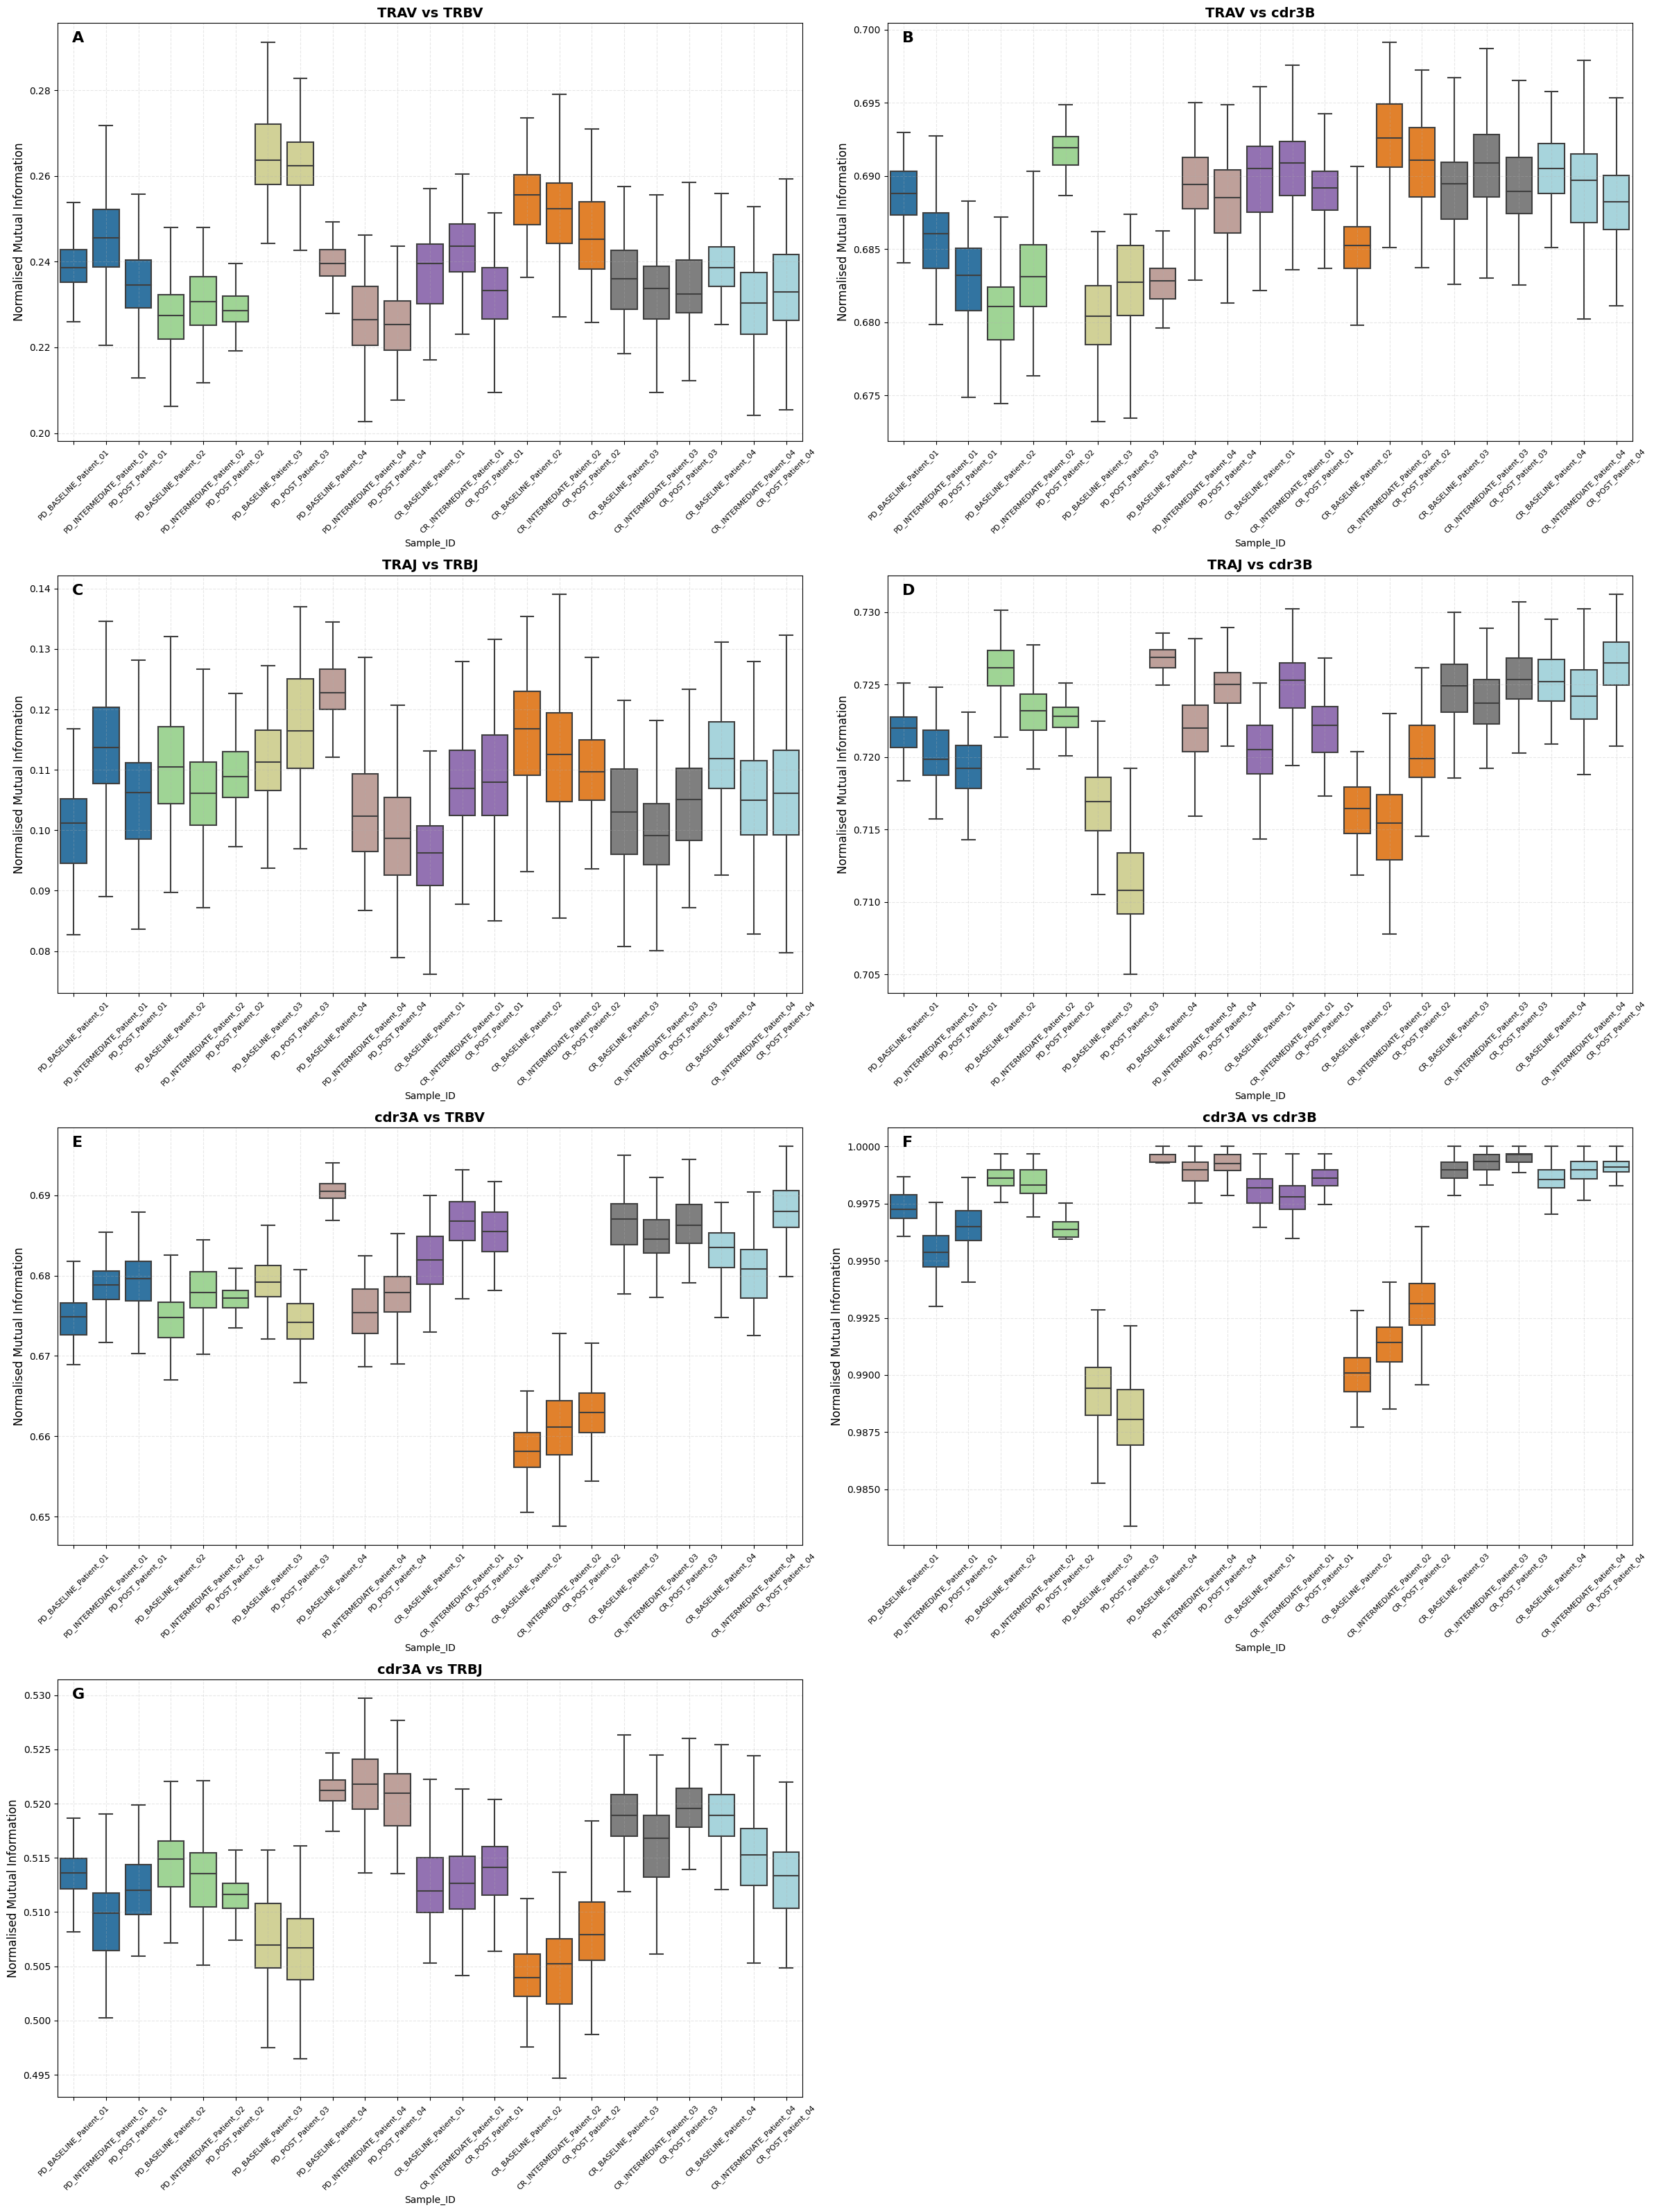

PD samples: 11, CR samples: 12
PD samples: 11, CR samples: 12
PD samples: 11, CR samples: 12
PD samples: 11, CR samples: 12
PD samples: 11, CR samples: 12
PD samples: 11, CR samples: 12
PD samples: 11, CR samples: 12
🔥 Combined heatmap saved: combined_heatmaps.pdf


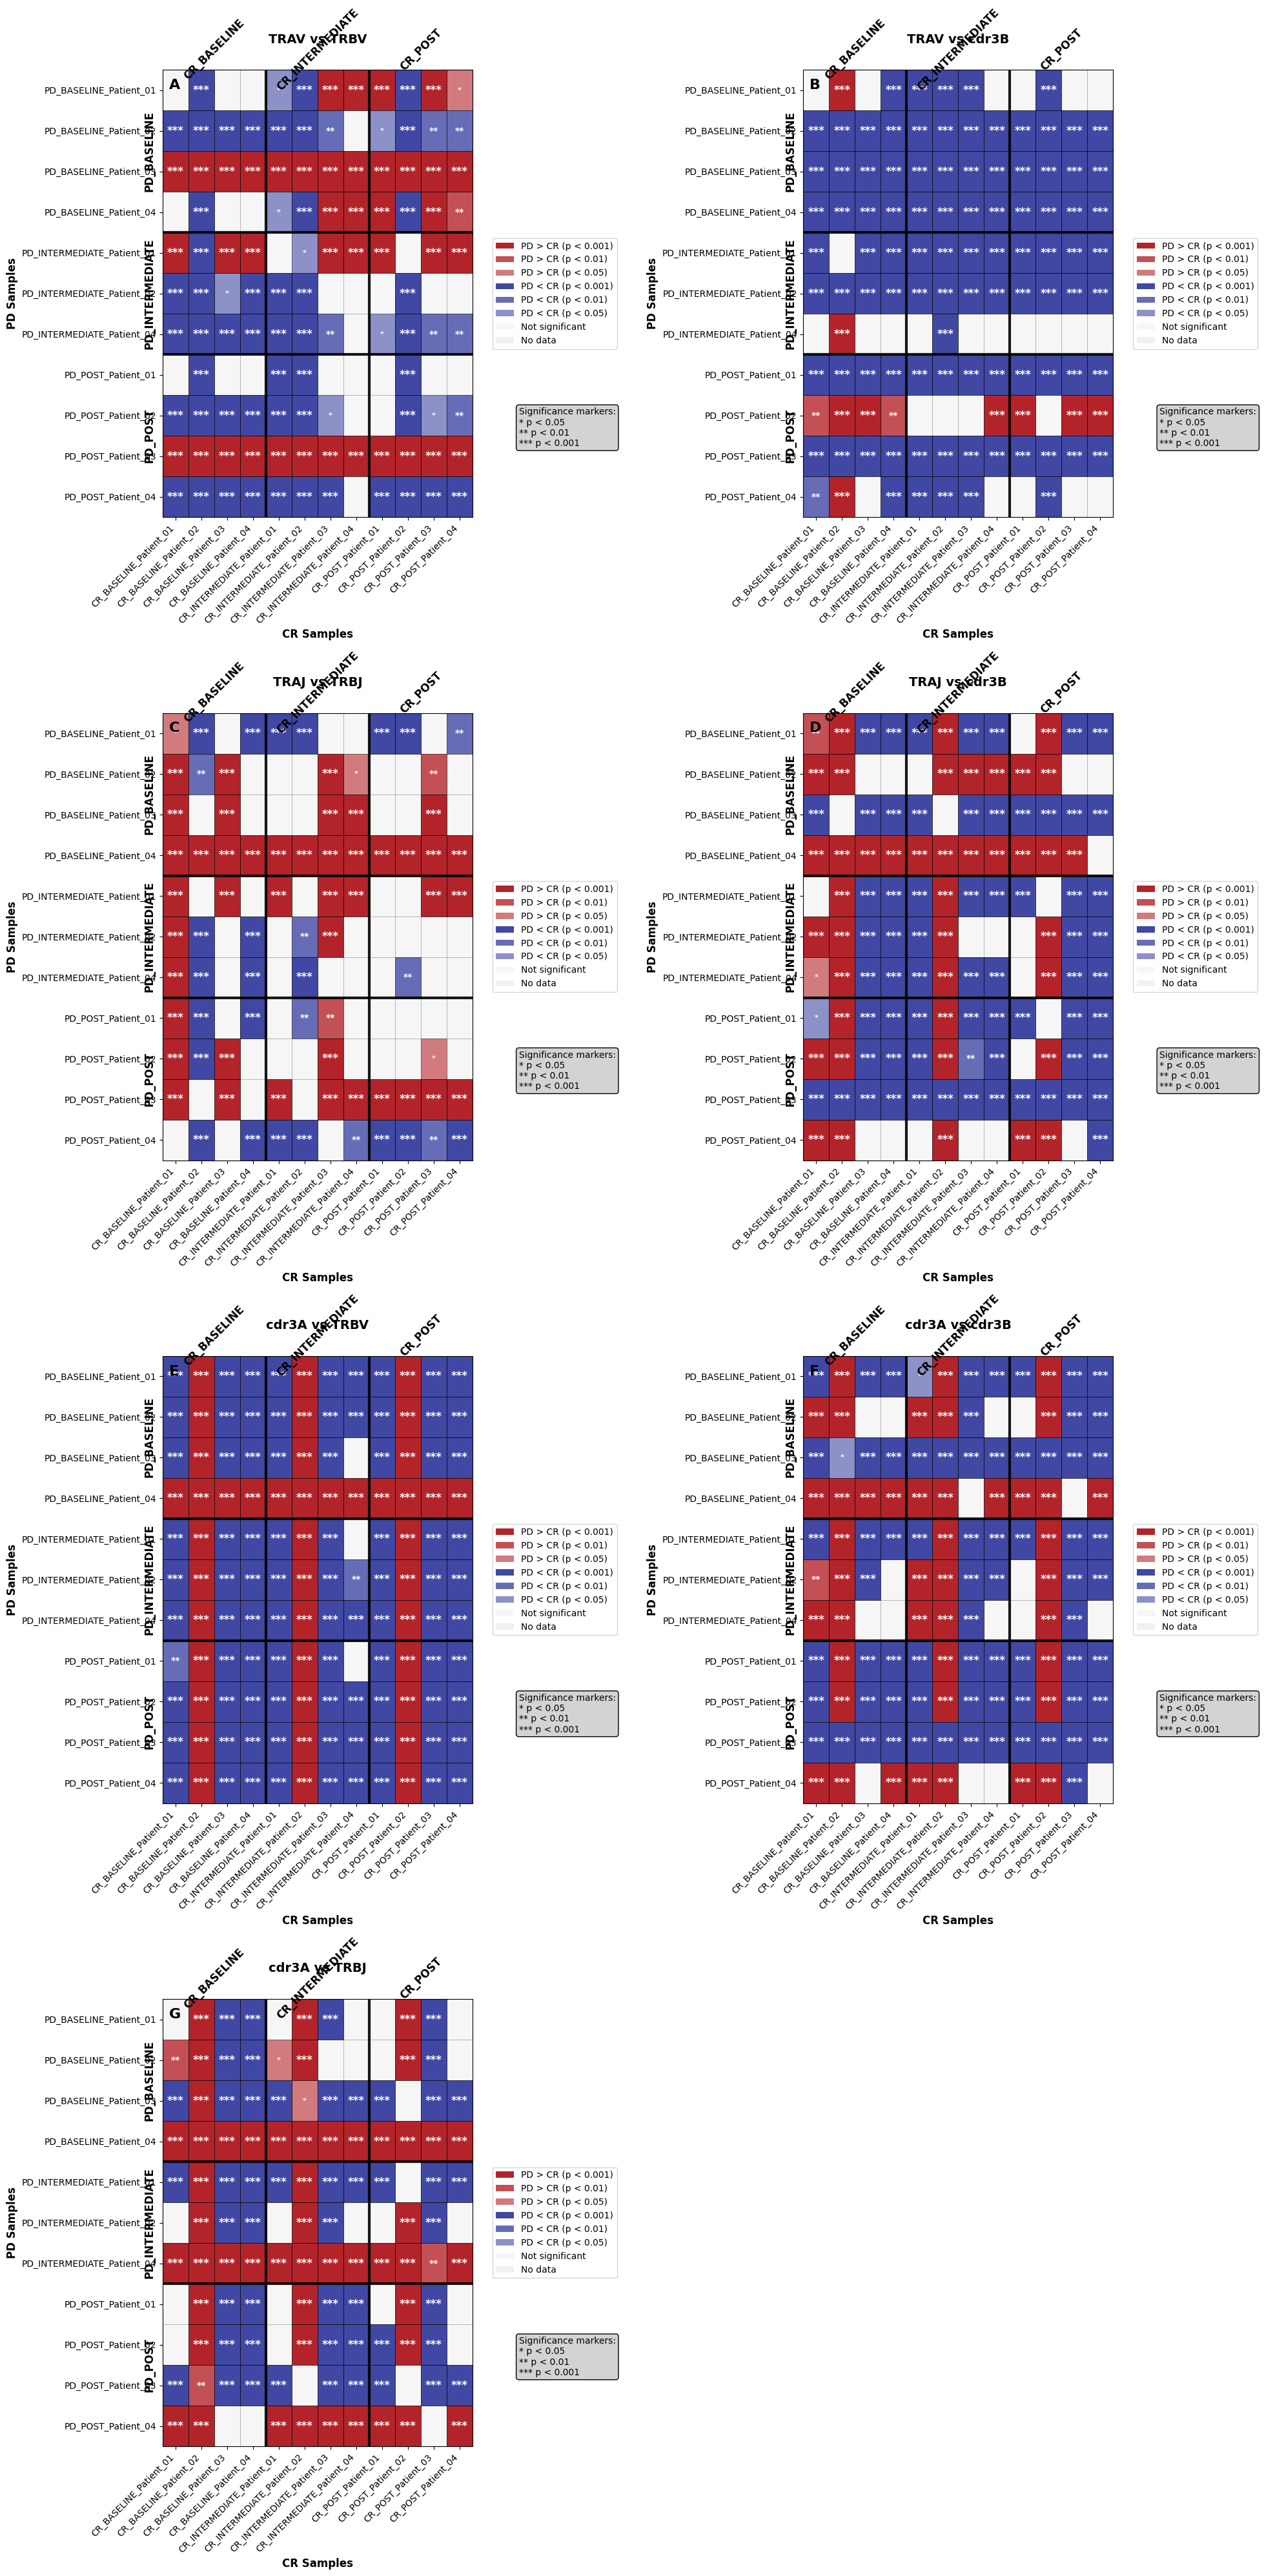


✅ Processing completed. All figures saved to: figures/cHL/samples/both


In [7]:
create_mi_boxplot("/mnt/d/TCRMI/results/cHL/samples/mi.pickle", 
                  "/mnt/d/TCRMI/results/cHL/samples.pickle",  
                  analysis_type='samples', selected_features=[('TRAV', 'TRBV'), ('cdr3A', 'cdr3B'),
                                                            ('TRAV', 'cdr3B'), ('cdr3A', 'TRBV'),
                                                            ('TRAJ', 'TRBJ'), ('cdr3A', 'TRBJ'),
                                                            ('TRAJ', 'cdr3B'),],
                    treatment_filter="both", save_dir="figures/cHL/samples/both") #"figures/cHL/samples"

Processing TRAV vs TRBV: 6 samples
Processing TRAV vs cdr3B: 6 samples
Processing TRAJ vs TRBJ: 6 samples
Processing TRAJ vs cdr3B: 6 samples
Processing cdr3A vs TRBV: 6 samples
Processing cdr3A vs cdr3B: 6 samples


/tmp/ipykernel_1737384/787506231.py:730: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


Processing cdr3A vs TRBJ: 6 samples
📊 Combined boxplot saved: combined_boxplots.pdf


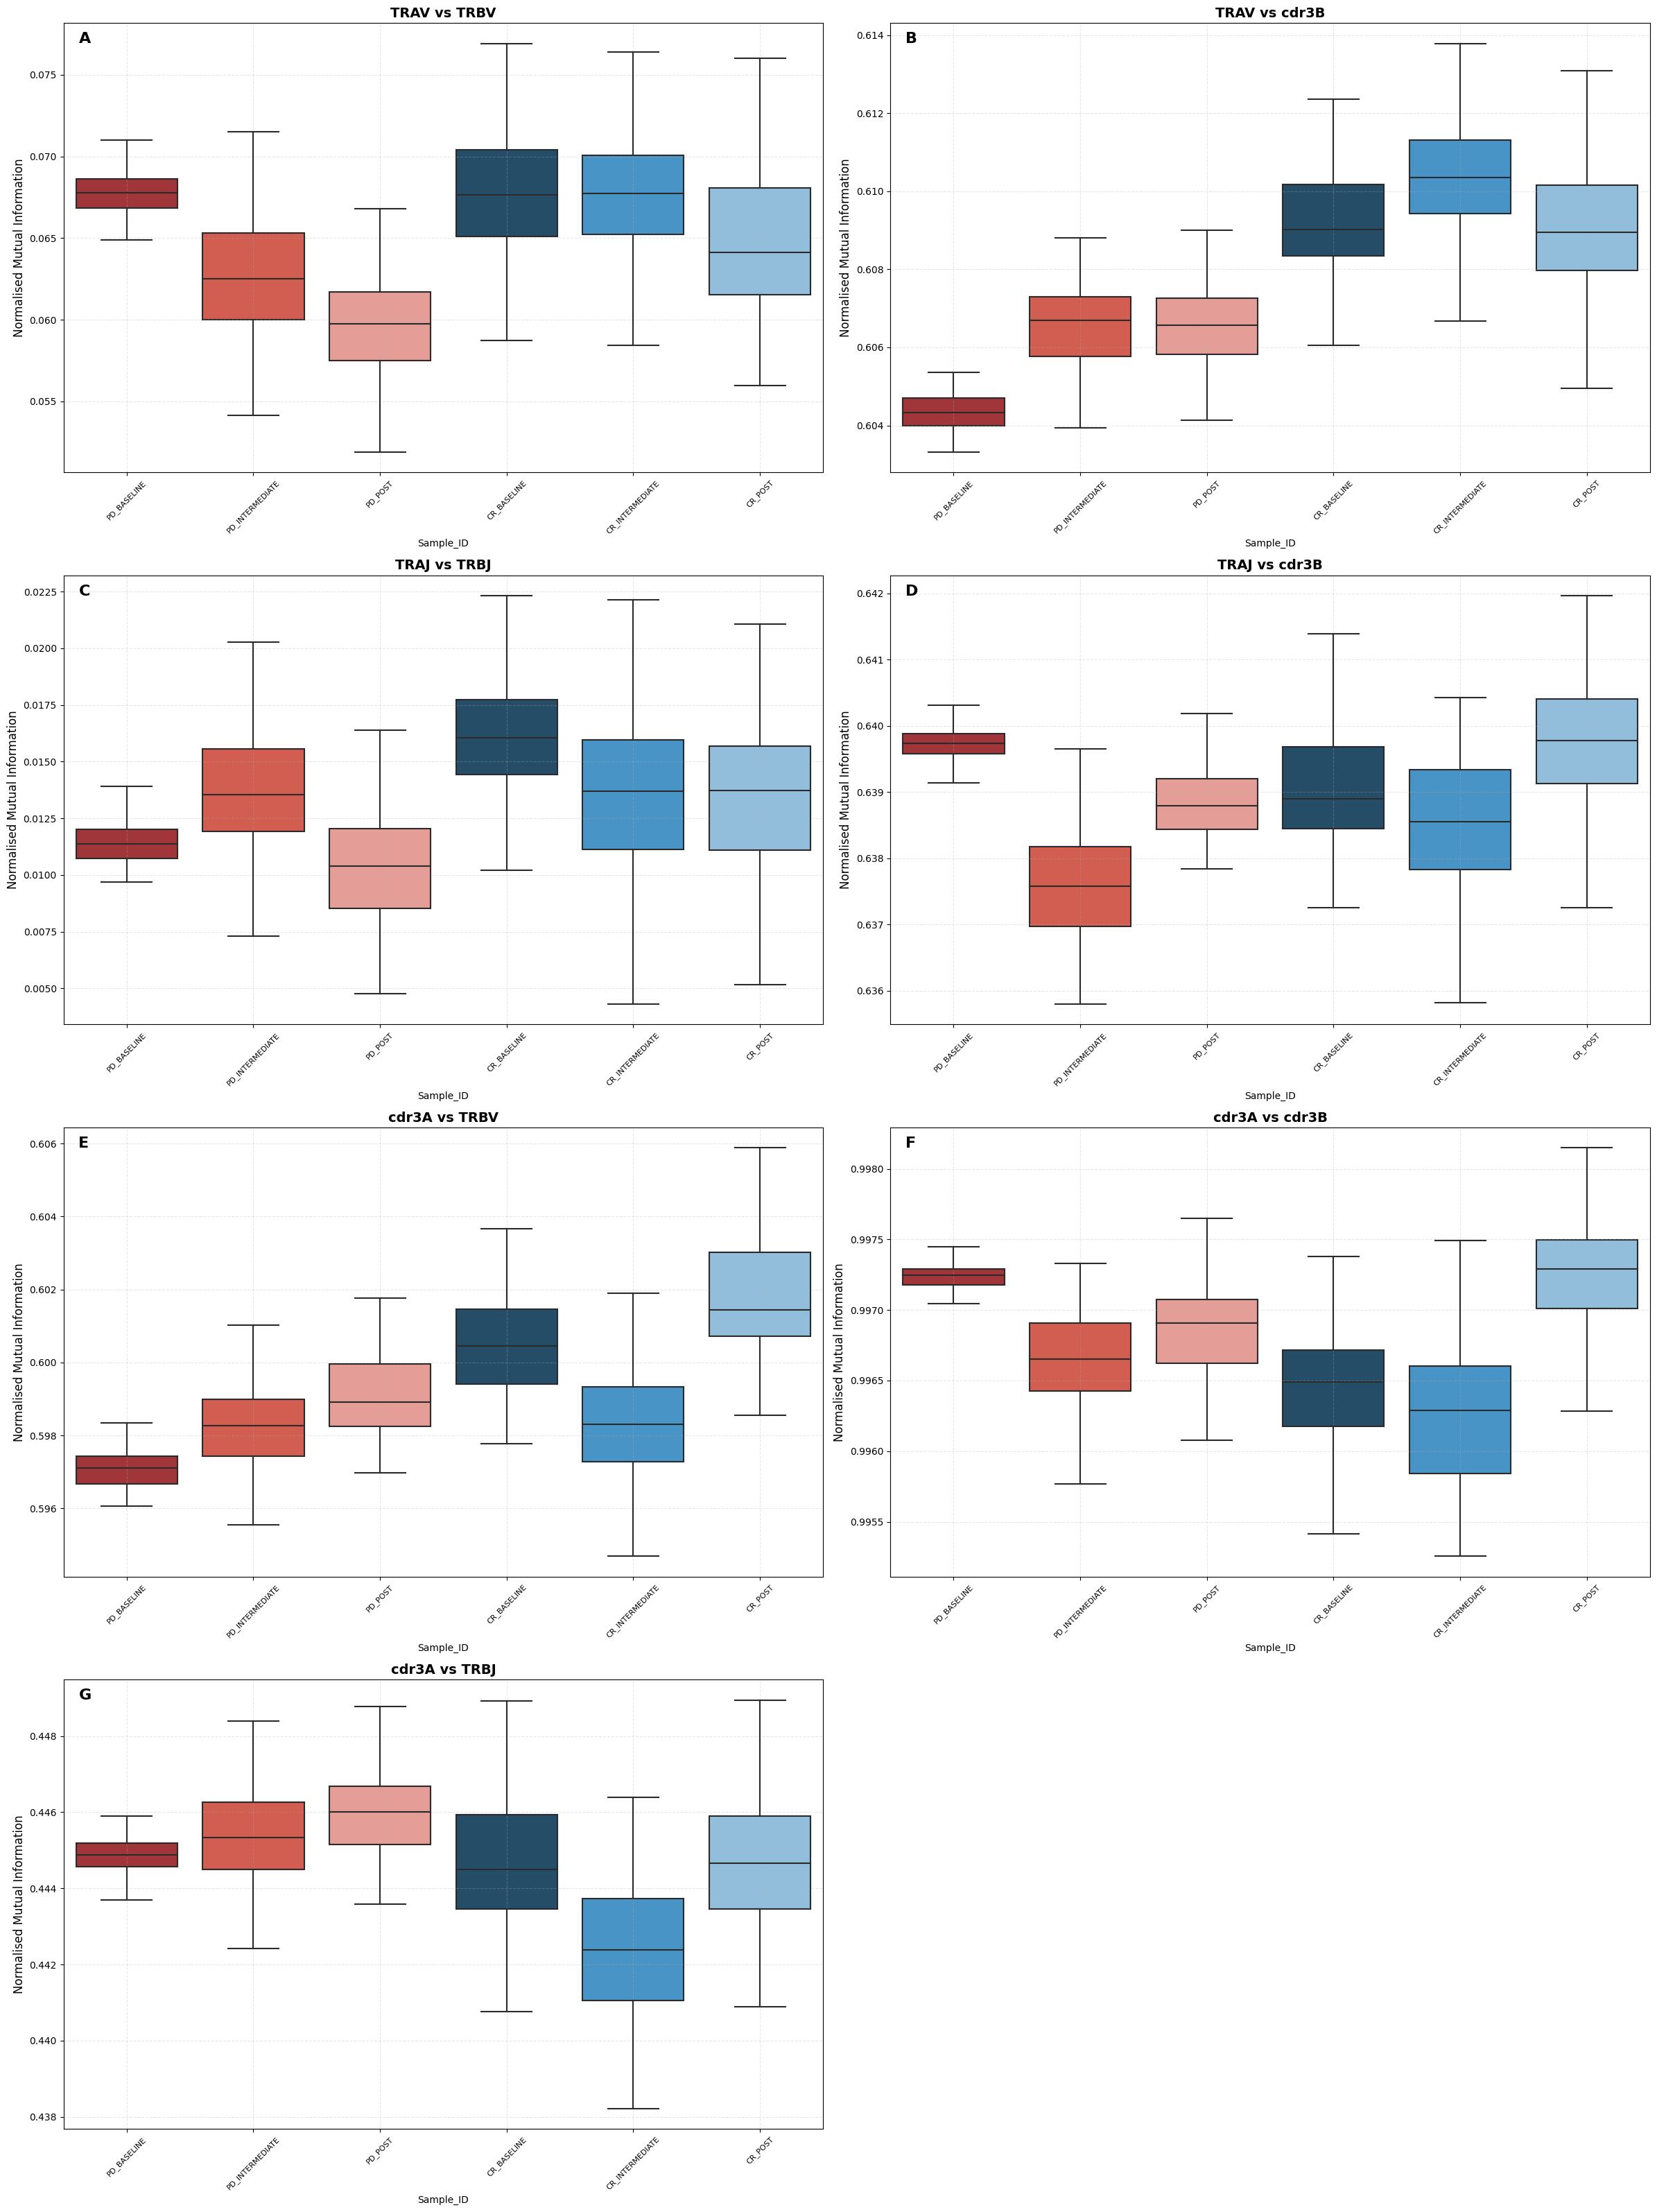

🔥 Combined heatmap saved: combined_heatmaps.pdf


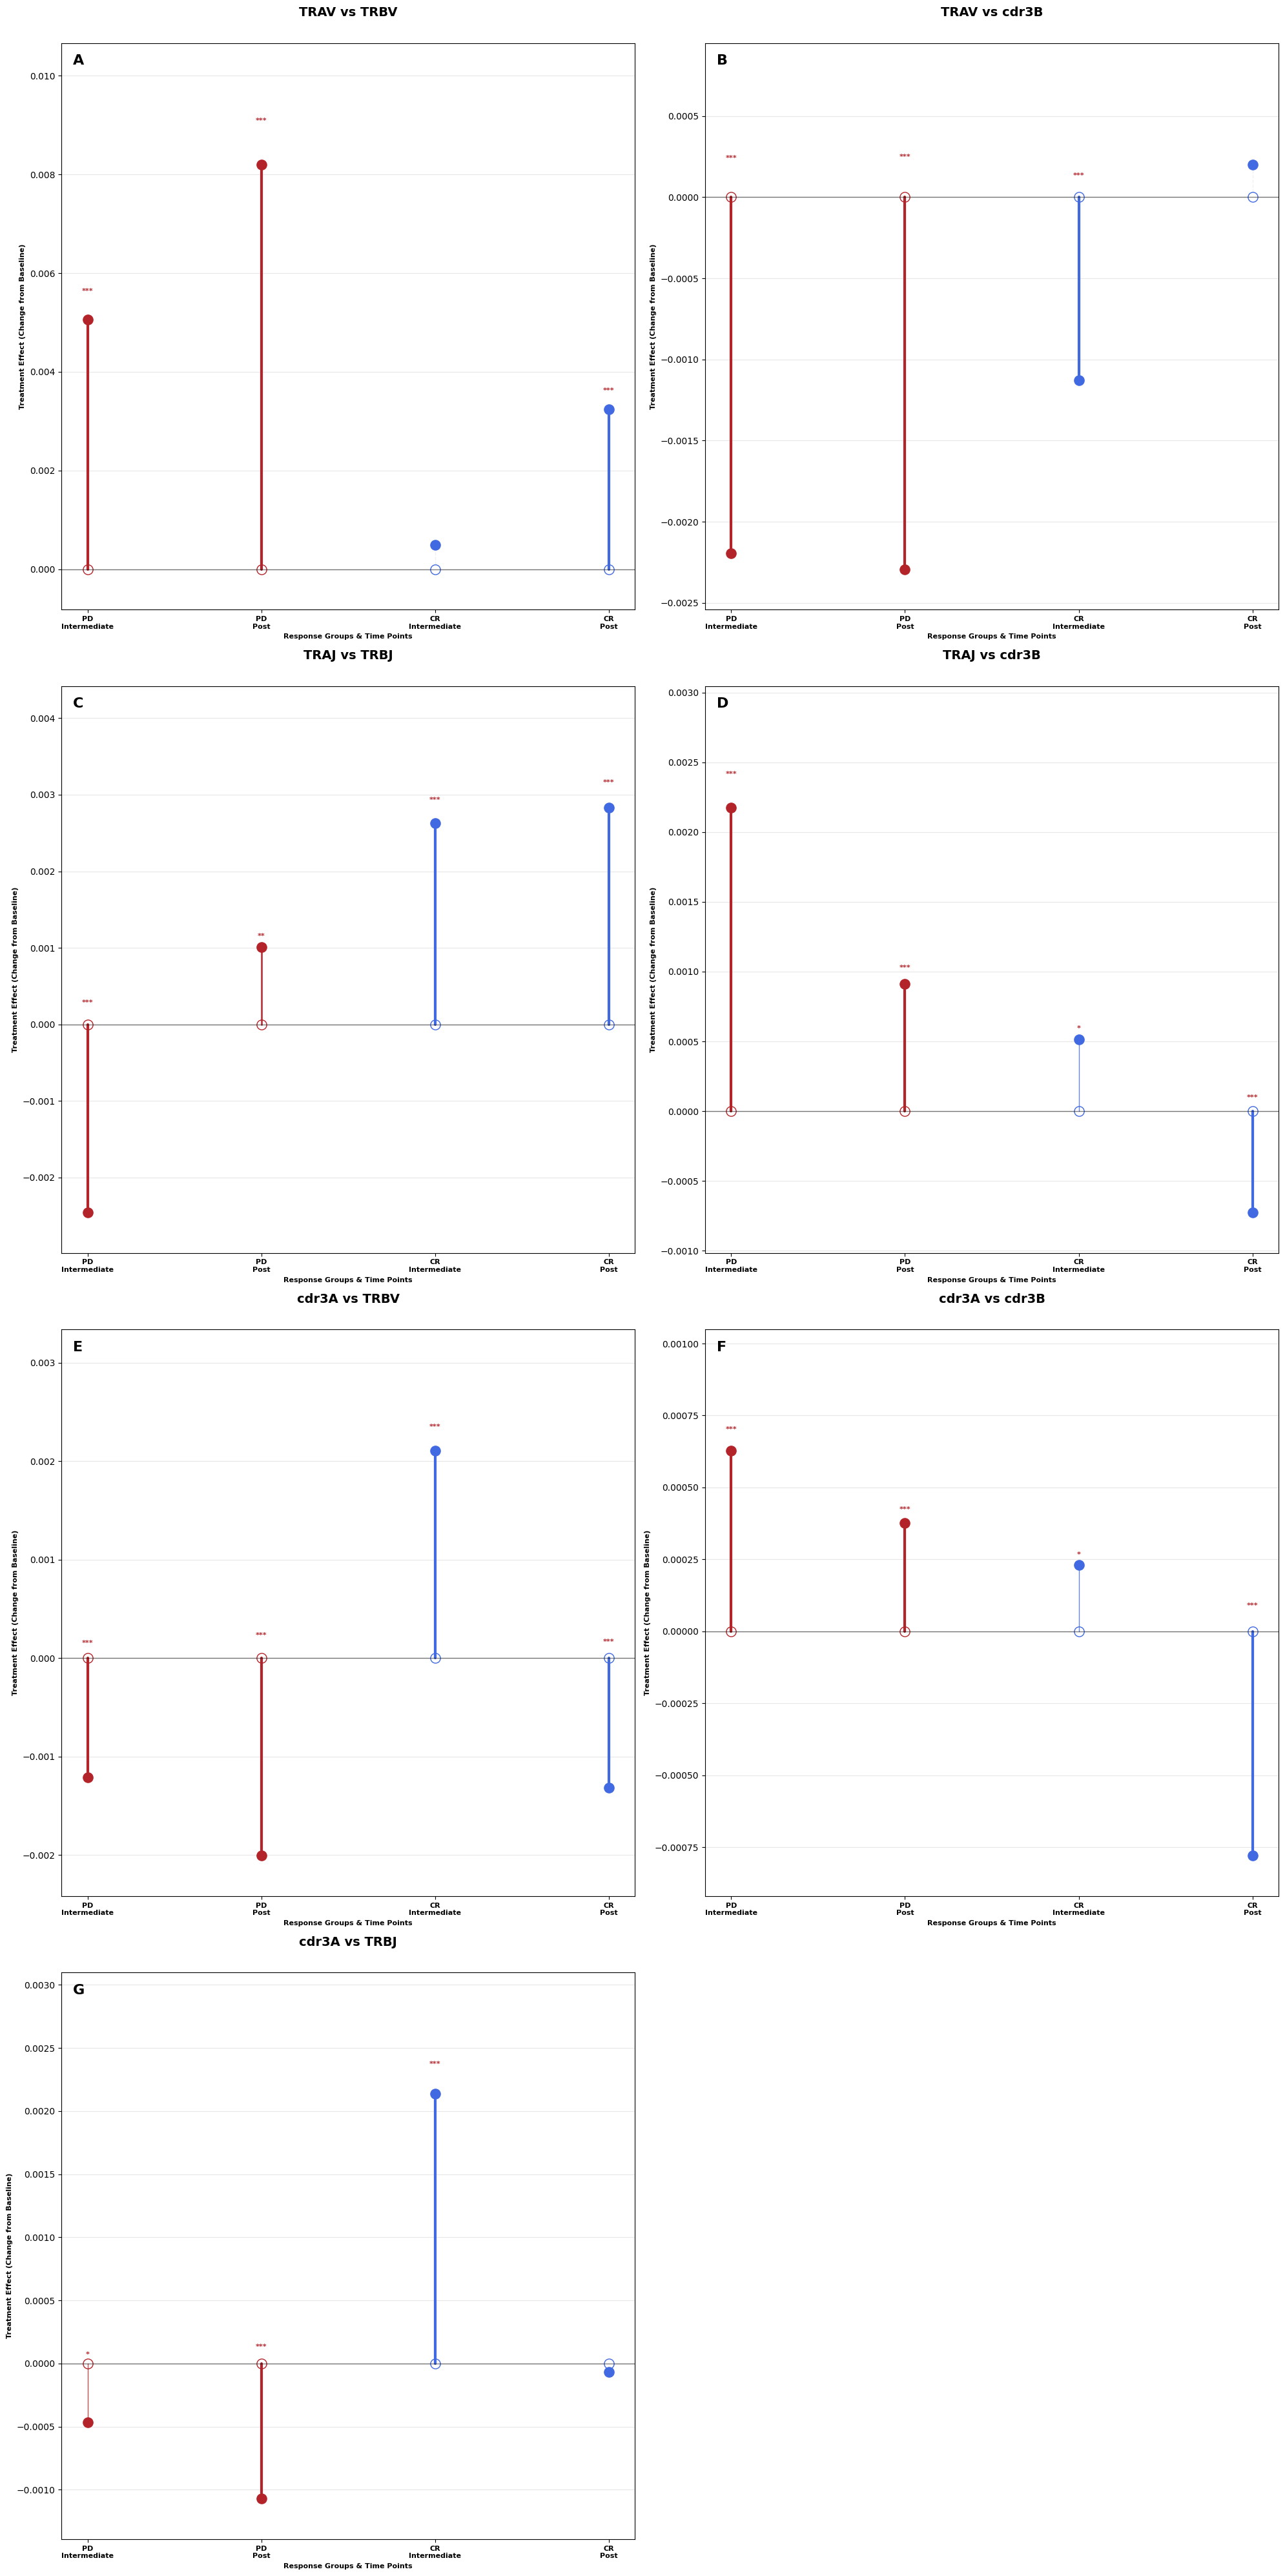


✅ Processing completed. All figures saved to: figures/cHL/cohort


In [6]:
create_mi_boxplot("/mnt/d/TCRMI/results/cHL/cohort/mi.pickle", 
                  "/mnt/d/TCRMI/results/cHL/cohort.pickle",  
                  analysis_type='cohort', selected_features=[('TRAV', 'TRBV'), ('cdr3A', 'cdr3B'),
                                                            ('TRAV', 'cdr3B'), ('cdr3A', 'TRBV'),
                                                            ('TRAJ', 'TRBJ'), ('cdr3A', 'TRBJ'),
                                                            ('TRAJ', 'cdr3B'),],
                    treatment_filter="both", save_dir="figures/cHL/cohort") #"figures/cHL/samples"

# NPMI

In [8]:
F_TRBVs = tt.tr.query(contains_pattern="TRBV", functionality="F", precision="gene")
F_TRAVs = tt.tr.query(contains_pattern="TRAV", functionality="F", precision="gene")

F_TRBJs = tt.tr.query(contains_pattern="TRBJ", functionality="F", precision="gene")
F_TRAJs = tt.tr.query(contains_pattern="TRAJ", functionality="F", precision="gene")

In [12]:
def permutation_test_matrices(matrices1, matrices2, n_permutations=10000, random_state=42):
    """
    Perform permutation test comparing two sets of NPMI matrices
    
    Parameters:
    -----------
    matrices1: list of 2D numpy arrays (NPMI matrices from resamples)
    matrices2: list of 2D numpy arrays (NPMI matrices from resamples)
    n_permutations: number of permutations for the test
    random_state: random seed
    
    Returns:
    --------
    tuple: (significant_positions, p_values, observed_differences)
    """
    if len(matrices1) == 0 or len(matrices2) == 0:
        return None, None, None
    
    np.random.seed(random_state)
    
    # Stack matrices to get 3D arrays (n_resamples, n_genes1, n_genes2)
    stack1 = np.stack(matrices1)
    stack2 = np.stack(matrices2)
    
    # Get matrix dimensions
    n_genes1, n_genes2 = stack1.shape[1], stack1.shape[2]
    
    # Calculate observed differences (matrices2 - matrices1) for each gene pair
    means1 = np.mean(stack1, axis=0)
    means2 = np.mean(stack2, axis=0)
    observed_diff = means2 - means1
    
    # Initialize result arrays
    p_values = np.full((n_genes1, n_genes2), np.nan)
    significant_positions = np.zeros((n_genes1, n_genes2), dtype=bool)
    
    # Combine all values for permutation
    all_matrices = np.concatenate([stack1, stack2], axis=0)
    n_matrices1 = len(matrices1)
    n_matrices2 = len(matrices2)
    n_total = n_matrices1 + n_matrices2
    
    # Test each gene pair position
    for i in range(n_genes1):
        for j in range(n_genes2):
            # Get values for this gene pair across all resamples
            values1 = stack1[:, i, j]
            values2 = stack2[:, i, j]
            all_values = all_matrices[:, i, j]
            
            # Calculate observed test statistic (difference in means)
            obs_stat = np.mean(values2) - np.mean(values1)
            
            # Permutation test
            perm_stats = []
            for _ in range(n_permutations):
                # Randomly shuffle the combined data
                shuffled_indices = np.random.permutation(n_total)
                shuffled_values = all_values[shuffled_indices]
                
                # Split into two groups
                pseudo_group1 = shuffled_values[:n_matrices1]
                pseudo_group2 = shuffled_values[n_matrices1:]
                
                # Calculate permuted test statistic
                perm_stat = np.mean(pseudo_group2) - np.mean(pseudo_group1)
                perm_stats.append(perm_stat)
            
            # Calculate p-value (two-tailed test)
            perm_stats = np.array(perm_stats)
            p_val = np.mean(np.abs(perm_stats) >= np.abs(obs_stat))
            p_values[i, j] = p_val
            
            # Check significance (you can adjust alpha as needed)
            if p_val < 0.05:
                significant_positions[i, j] = True
    
    return significant_positions, p_values, observed_diff

def get_response_category(sample_id):
    """Extract response category from sample ID"""
    if "PD_BASELINE" in sample_id:
        return "PD_BASELINE"
    elif "PD_INTERMEDIATE" in sample_id:
        return "PD_INTERMEDIATE"
    elif "PD_POST" in sample_id:
        return "PD_POST"
    elif "CR_BASELINE" in sample_id:
        return "CR_BASELINE"
    elif "CR_INTERMEDIATE" in sample_id:
        return "CR_INTERMEDIATE"
    elif "CR_POST" in sample_id:
        return "CR_POST"
    
    return sample_id

def get_patient_timepoints(sample_ids):
    """
    Get patients with BASELINE, INTERMEDIATE, and/or POST samples
    
    Returns:
    --------
    dict: {patient_id: {'timepoints': {timepoint: sample_id}, 'response_type': str}}
    """
    paired_patients = {}
    
    # Group samples by patient ID
    patient_samples = defaultdict(list)
    for sample_id in sample_ids:
        try:
            patient_id = get_patient_id(sample_id)
            response_category = get_response_category(sample_id)
            
            # Extract timepoint and response type
            if response_category.startswith('PD_'):
                response_type = 'PD'
                timepoint = response_category.replace('PD_', '')
            elif response_category.startswith('CR_'):
                response_type = 'CR'
                timepoint = response_category.replace('CR_', '')
            else:
                continue  # Skip if not matching expected format
            
            patient_samples[patient_id].append({
                'sample_id': sample_id,
                'timepoint': timepoint,
                'response_type': response_type,
                'response_category': response_category
            })
        except Exception as e:
            print(f"Warning: Could not process sample {sample_id}: {e}")
            continue
    
    # Find patients with multiple timepoints
    for patient_id, samples in patient_samples.items():
        # Group by timepoint
        timepoint_dict = {}
        response_type = None
        
        for sample in samples:
            timepoint_dict[sample['timepoint']] = sample['sample_id']
            if response_type is None:
                response_type = sample['response_type']
        
        # Only include patients with at least 2 timepoints
        if len(timepoint_dict) >= 2:
            paired_patients[patient_id] = {
                'timepoints': timepoint_dict,
                'response_type': response_type
            }
    
    return paired_patients

def process_single_patient_feature_pair_timepoints(patient_id, feature_pair, patient_info, sample_ids, 
                                                  sample_data, n_resamples, n_permutations):
    """
    Process a single patient-feature pair combination for multiple timepoints
    """
    timepoints = patient_info['timepoints']
    response_type = patient_info['response_type']
    
    # Find sample indices for all available timepoints
    sample_indices = {}
    try:
        for timepoint, sample_id in timepoints.items():
            sample_indices[timepoint] = sample_ids.index(sample_id)
    except ValueError as e:
        return patient_id, feature_pair, None, f"Could not find sample indices: {e}"
    print(patient_id, sample_indices)
    
    # Collect NPMI matrices for all timepoints and resamples
    timepoint_matrices = {}
    for timepoint, sample_idx in sample_indices.items():
        matrices = []
        for resample_idx in range(n_resamples):
            if resample_idx in sample_data:
                matrices_list = sample_data[resample_idx]
                if sample_idx < len(matrices_list):
                    matrices.append(matrices_list[sample_idx])
        timepoint_matrices[timepoint] = matrices
    
    # Perform pairwise comparisons between timepoints
    comparisons = {}
    timepoint_list = list(timepoints.keys())
    
    for i, tp1 in enumerate(timepoint_list):
        for j, tp2 in enumerate(timepoint_list):
            if i < j:  # Avoid duplicate comparisons
                matrices1 = timepoint_matrices[tp1]
                matrices2 = timepoint_matrices[tp2]
                
                if len(matrices1) > 0 and len(matrices2) > 0:
                    significant_positions, p_values, observed_diff = permutation_test_matrices(
                        matrices1, matrices2, n_permutations, random_state=42
                    )
                    
                    if significant_positions is not None:
                        significant_count = np.sum(significant_positions)
                        total_tested = np.sum(~np.isnan(p_values))
                        
                        comparison_key = f"{tp1}_vs_{tp2}"
                        comparisons[comparison_key] = {
                            'significant_count': significant_count,
                            'total_tested': total_tested,
                            'percentage_changed': (significant_count / total_tested * 100) if total_tested > 0 else 0,
                            'significant_positions': significant_positions,
                            'p_values': p_values,
                            'observed_differences': observed_diff,
                            'timepoint1': tp1,
                            'timepoint2': tp2,
                            'sample_id1': timepoints[tp1],
                            'sample_id2': timepoints[tp2]
                        }
    
    if comparisons:
        result = {
            'comparisons': comparisons,
            'response_type': response_type,
            'available_timepoints': list(timepoints.keys()),
            'timepoint_samples': timepoints
        }
        return patient_id, feature_pair, result, None
    else:
        return patient_id, feature_pair, None, "No valid comparisons found"

def analyze_patient_npmi_changes_timepoints(npmi_data, data_dict, n_permutations=10000, alpha=0.05, n_jobs=-1):
    """
    Analyze NPMI changes for each patient across BASELINE, INTERMEDIATE, and POST timepoints
    
    Parameters:
    -----------
    npmi_data: dict with feature pairs as keys
    data_dict: dict with sample data
    n_permutations: int, number of permutations for test
    alpha: float, significance level
    n_jobs: int, number of parallel jobs
    
    Returns:
    --------
    dict: {patient_id: {feature_pair: analysis_results}}
    """
    # Get sample IDs from data_dict
    sample_ids = list(data_dict.keys())
    print(f"Total samples available: {len(sample_ids)}")
    
    # Get patients with multiple timepoints
    paired_patients = get_patient_timepoints(sample_ids)
    print(f"Patients with multiple timepoints: {len(paired_patients)}")
    
    # Print response type and timepoint distribution
    response_counts = defaultdict(int)
    timepoint_combinations = defaultdict(int)
    
    for patient_id, info in paired_patients.items():
        response_counts[info['response_type']] += 1
        timepoints_str = "_".join(sorted(info['timepoints'].keys()))
        timepoint_combinations[timepoints_str] += 1
    
    print("Response type distribution:")
    for response_type, count in response_counts.items():
        print(f"  {response_type}: {count} patients")
    
    print("Timepoint combinations:")
    for combination, count in timepoint_combinations.items():
        print(f"  {combination}: {count} patients")
    
    # Prepare all tasks for parallel processing
    tasks = []
    
    for feature_pair in npmi_data.keys():
        feature1, feature2 = feature_pair
        print(f"Preparing tasks for feature pair: {feature1} vs {feature2}")
        
        # Get sample data for this feature pair
        sample_data = npmi_data[feature_pair]
        n_resamples = len(sample_data)
        
        for patient_id, patient_info in paired_patients.items():
            tasks.append((
                patient_id, feature_pair, patient_info, sample_ids, 
                sample_data, n_resamples, n_permutations
            ))
    
    print(f"Total tasks to process: {len(tasks)}")
    print(f"Running with {n_jobs} parallel jobs...")
    
    # Execute tasks in parallel
    parallel_results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(process_single_patient_feature_pair_timepoints)(
            patient_id, feature_pair, patient_info, sample_ids,
            sample_data, n_resamples, n_permutations
        ) for patient_id, feature_pair, patient_info, sample_ids, 
             sample_data, n_resamples, n_permutations in tasks
    )
    
    # Organize results
    results = defaultdict(lambda: defaultdict(dict))
    
    for patient_id, feature_pair, result, error in parallel_results:
        if result is not None:
            results[patient_id][feature_pair] = result
        else:
            print(f"Warning: Failed to process {patient_id} - {feature_pair}: {error}")
    
    print(f"\nCompleted processing for {len(results)} patients")
    
    return results

def summarize_patient_timepoint_changes(analysis_results):
    """
    Summarize significant changes across all feature pairs and timepoint comparisons for each patient
    
    Returns:
    --------
    pandas.DataFrame: Summary of changes per patient
    """
    summary_data = []
    
    for patient_id, feature_results in analysis_results.items():
        # Initialize summary variables
        response_type = None
        available_timepoints = None
        comparison_summaries = defaultdict(lambda: {'total_significant': 0, 'total_tested': 0})
        feature_summaries = {}
        
        for feature_pair, results in feature_results.items():
            feature_name = f"{feature_pair[0]}_{feature_pair[1]}"
            response_type = results['response_type']
            available_timepoints = results['available_timepoints']
            
            # Process each comparison for this feature pair
            for comparison_name, comparison_data in results['comparisons'].items():
                significant_count = comparison_data['significant_count']
                tested_count = comparison_data['total_tested']
                percentage = comparison_data['percentage_changed']
                
                # Add to comparison summary
                comparison_summaries[comparison_name]['total_significant'] += significant_count
                comparison_summaries[comparison_name]['total_tested'] += tested_count
                
                # Add to feature summary
                feature_key = f"{feature_name}_{comparison_name}"
                feature_summaries[f"{feature_key}_significant"] = significant_count
                feature_summaries[f"{feature_key}_tested"] = tested_count
                feature_summaries[f"{feature_key}_percentage"] = percentage
        
        # Calculate overall percentages for each comparison
        comparison_percentages = {}
        for comparison_name, summary in comparison_summaries.items():
            if summary['total_tested'] > 0:
                comparison_percentages[f"{comparison_name}_percentage"] = (
                    summary['total_significant'] / summary['total_tested'] * 100
                )
                comparison_percentages[f"{comparison_name}_significant"] = summary['total_significant']
                comparison_percentages[f"{comparison_name}_tested"] = summary['total_tested']
            else:
                comparison_percentages[f"{comparison_name}_percentage"] = 0
                comparison_percentages[f"{comparison_name}_significant"] = 0
                comparison_percentages[f"{comparison_name}_tested"] = 0
        
        # Create summary row
        summary_row = {
            'Patient_ID': patient_id,
            'Response_Type': response_type,
            'Available_Timepoints': "_".join(sorted(available_timepoints)) if available_timepoints else "",
            **comparison_percentages,
            **feature_summaries
        }
        
        summary_data.append(summary_row)
    
    return pd.DataFrame(summary_data)

def save_timepoint_results(analysis_results, summary_df, output_dir):
    """Save analysis results for timepoint comparisons"""
    os.makedirs(output_dir, exist_ok=True)
    
    # Convert defaultdict to regular dict for pickling
    regular_dict_results = {}
    for patient_id, feature_results in analysis_results.items():
        regular_dict_results[patient_id] = dict(feature_results)
    
    # Save detailed results
    with open(os.path.join(output_dir, 'patient_timepoint_changes_detailed.pickle'), 'wb') as f:
        pickle.dump(regular_dict_results, f)
    
    # Save summary
    summary_df.to_csv(os.path.join(output_dir, 'patient_timepoint_changes_summary.csv'), index=False)

def create_timepoint_comparison_heatmap(summary_df, comparison_column, save_path=None):
    """
    Create a heatmap showing percentage changes for a specific timepoint comparison
    
    Parameters:
    -----------
    summary_df: pandas.DataFrame with patient data
    comparison_column: str, column name for the comparison (e.g., 'BASELINE_vs_POST_percentage')
    save_path: str, optional path to save the figure
    """
    # Filter data
    df_clean = summary_df.dropna(subset=[comparison_column, 'Response_Type'])
    
    if len(df_clean) == 0:
        print("No valid data found for plotting")
        return
    
    # Separate by response type
    pd_patients = df_clean[df_clean['Response_Type'] == 'PD']
    cr_patients = df_clean[df_clean['Response_Type'] == 'CR']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
    
    # Plot PD patients
    if len(pd_patients) > 0:
        pd_values = pd_patients[comparison_column].values
        pd_ids = pd_patients['Patient_ID'].values
        
        bars1 = ax1.bar(range(len(pd_patients)), pd_values, color='#DC143C', alpha=0.7)
        ax1.set_title(f'PD Patients - {comparison_column.replace("_", " ")}', fontweight='bold')
        ax1.set_xlabel('Patient')
        ax1.set_ylabel('Percentage Changed (%)')
        ax1.set_xticks(range(len(pd_patients)))
        ax1.set_xticklabels(pd_ids, rotation=45, ha='right')
        
        # Add value labels on bars
        for bar, value in zip(bars1, pd_values):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{value:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Plot CR patients
    if len(cr_patients) > 0:
        cr_values = cr_patients[comparison_column].values
        cr_ids = cr_patients['Patient_ID'].values
        
        bars2 = ax2.bar(range(len(cr_patients)), cr_values, color='#4169E1', alpha=0.7)
        ax2.set_title(f'CR Patients - {comparison_column.replace("_", " ")}', fontweight='bold')
        ax2.set_xlabel('Patient')
        ax2.set_ylabel('Percentage Changed (%)')
        ax2.set_xticks(range(len(cr_patients)))
        ax2.set_xticklabels(cr_ids, rotation=45, ha='right')
        
        # Add value labels on bars
        for bar, value in zip(bars2, cr_values):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{value:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Figure saved to: {save_path}")
    


In [13]:
npmi_data = pd.read_pickle("/mnt/d/TCRMI/results/cHL/samples/npmi.pickle")
data_dict = pd.read_pickle("/mnt/d/TCRMI/results/cHL/samples.pickle")

In [14]:
paired_patients = get_patient_timepoints(data_dict.keys())

In [15]:
results = analyze_patient_npmi_changes_timepoints(
    npmi_data=npmi_data,
    data_dict=data_dict,
    n_permutations=10000,
    n_jobs=-1
)
summary_df = summarize_patient_timepoint_changes(results)

Total samples available: 23
Patients with multiple timepoints: 8
Response type distribution:
  PD: 4 patients
  CR: 4 patients
Timepoint combinations:
  BASELINE_INTERMEDIATE_POST: 7 patients
  BASELINE_POST: 1 patients
Preparing tasks for feature pair: TRAV vs TRBV
Preparing tasks for feature pair: TRAJ vs TRBJ
Total tasks to process: 16
Running with -1 parallel jobs...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


PD_Patient_01 {'BASELINE': 0, 'POST': 1, 'INTERMEDIATE': 21}
CR_Patient_02 {'BASELINE': 2, 'POST': 3, 'INTERMEDIATE': 20}
PD_Patient_02 {'BASELINE': 4, 'POST': 5, 'INTERMEDIATE': 18}
CR_Patient_01 {'BASELINE': 6, 'POST': 7, 'INTERMEDIATE': 17}
PD_Patient_04 {'BASELINE': 8, 'POST': 9, 'INTERMEDIATE': 16}
CR_Patient_03 {'BASELINE': 10, 'POST': 11, 'INTERMEDIATE': 22}
PD_Patient_03 {'BASELINE': 12, 'POST': 13}
CR_Patient_04 {'BASELINE': 14, 'POST': 15, 'INTERMEDIATE': 19}
PD_Patient_01 {'BASELINE': 0, 'POST': 1, 'INTERMEDIATE': 21}
CR_Patient_02 {'BASELINE': 2, 'POST': 3, 'INTERMEDIATE': 20}
PD_Patient_02 {'BASELINE': 4, 'POST': 5, 'INTERMEDIATE': 18}
CR_Patient_01 {'BASELINE': 6, 'POST': 7, 'INTERMEDIATE': 17}
PD_Patient_04 {'BASELINE': 8, 'POST': 9, 'INTERMEDIATE': 16}
CR_Patient_03 {'BASELINE': 10, 'POST': 11, 'INTERMEDIATE': 22}
PD_Patient_03 {'BASELINE': 12, 'POST': 13}
CR_Patient_04 {'BASELINE': 14, 'POST': 15, 'INTERMEDIATE': 19}

Completed processing for 8 patients


[Parallel(n_jobs=-1)]: Done  16 out of  16 | elapsed: 35.8min finished


In [19]:
save_timepoint_results(results, summary_df, "results/cHL/samples")

In [16]:
analysis_results = pd.read_pickle("results/cHL/samples/patient_timepoint_changes_detailed.pickle")
df = pd.read_csv("/mnt/d/TCRMI/results/cHL/samples/patient_timepoint_changes_summary.csv")

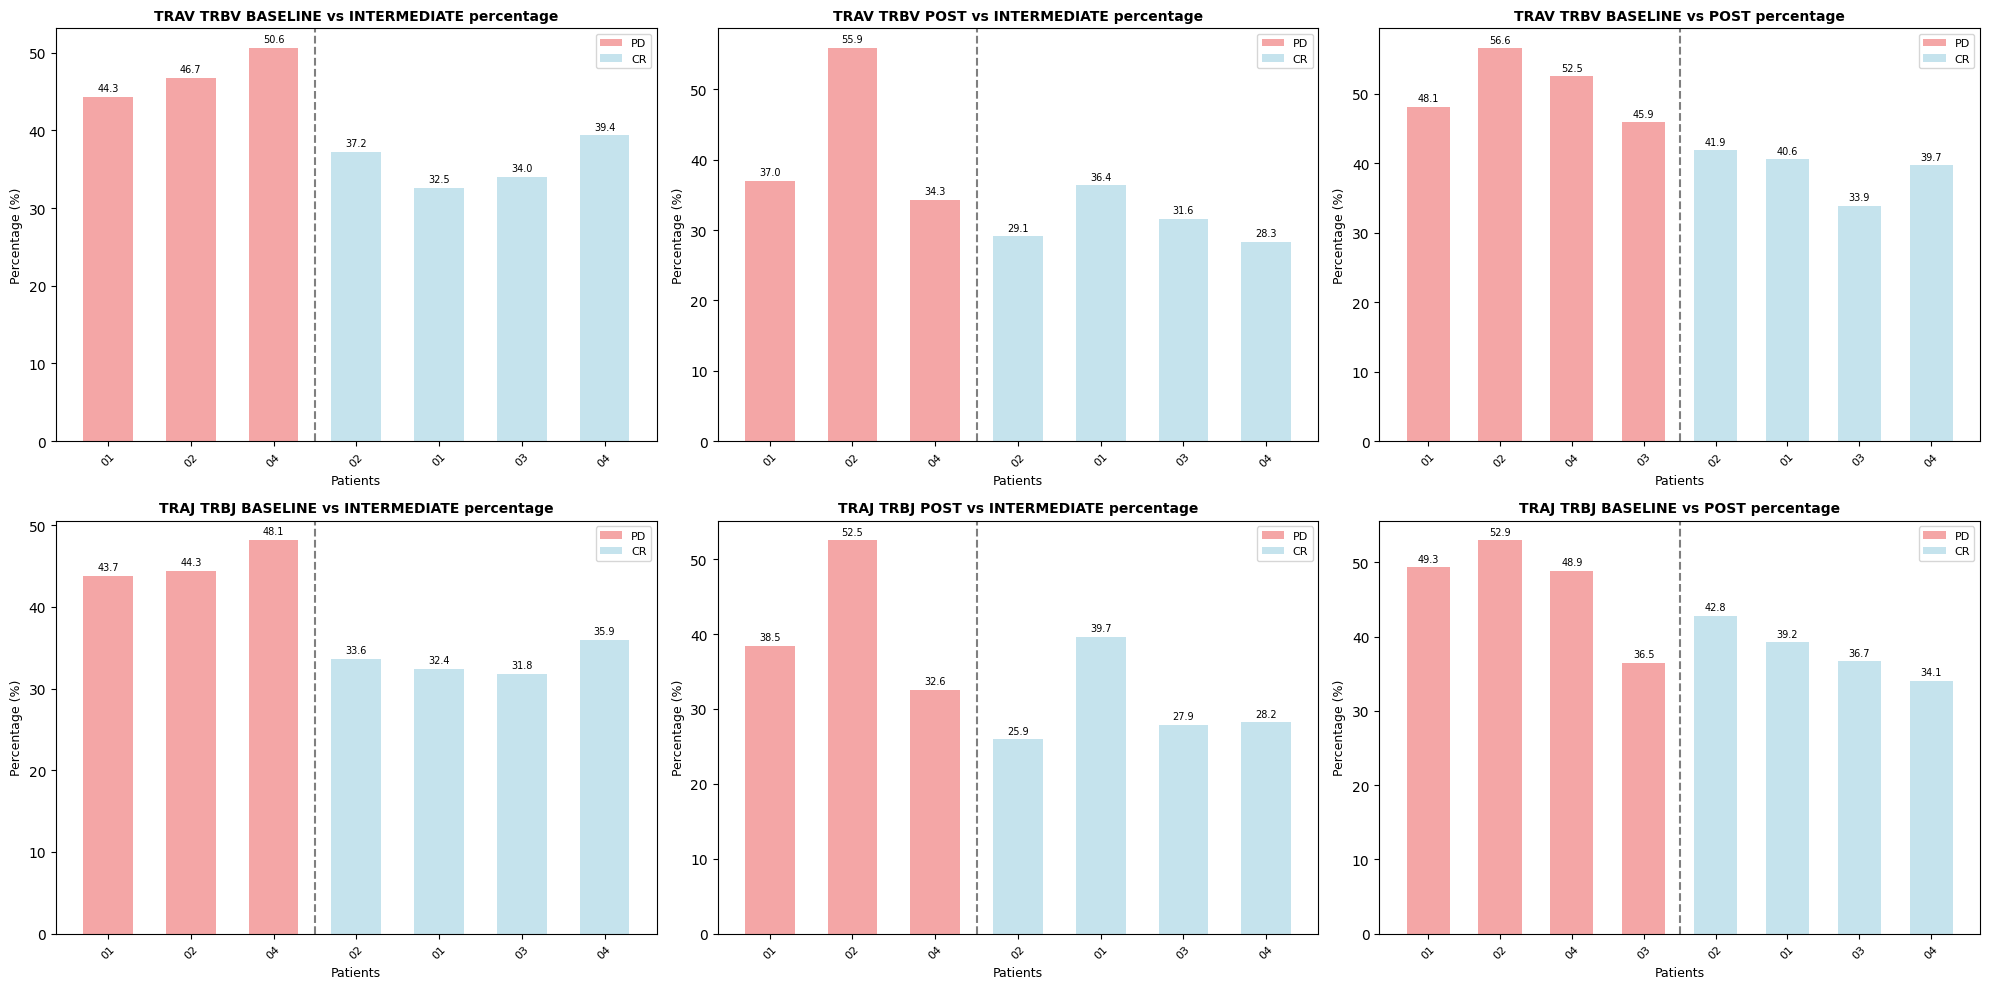

In [20]:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

percentage_columns = ['TRAV_TRBV_BASELINE_vs_INTERMEDIATE_percentage',
                         'TRAV_TRBV_POST_vs_INTERMEDIATE_percentage',
                         'TRAV_TRBV_BASELINE_vs_POST_percentage',
                         'TRAJ_TRBJ_BASELINE_vs_INTERMEDIATE_percentage',
                         'TRAJ_TRBJ_POST_vs_INTERMEDIATE_percentage',
                         'TRAJ_TRBJ_BASELINE_vs_POST_percentage']

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

# Create charts for each percentage metric
for i, col in enumerate(percentage_columns):
    ax = axes[i]
    
    # Separate PD and CR data
    pd_data = df[df['Response_Type'] == 'PD'][col].dropna()
    cr_data = df[df['Response_Type'] == 'CR'][col].dropna()
    
    # Create patient ID labels
    pd_patients = df[df['Response_Type'] == 'PD']['Patient_ID'].iloc[:len(pd_data)]
    cr_patients = df[df['Response_Type'] == 'CR']['Patient_ID'].iloc[:len(cr_data)]
    
    # Create bar plots
    x_pos_pd = np.arange(len(pd_data))
    x_pos_cr = np.arange(len(pd_data), len(pd_data) + len(cr_data))
    
    bars_pd = ax.bar(x_pos_pd, pd_data, alpha=0.7, color='lightcoral', label='PD', width=0.6)
    bars_cr = ax.bar(x_pos_cr, cr_data, alpha=0.7, color='lightblue', label='CR', width=0.6)
    
    # Set labels and title
    ax.set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=9)
    ax.set_xlabel('Patients', fontsize=9)
    
    # Set x-axis labels
    all_patients = list(pd_patients) + list(cr_patients)
    ax.set_xticks(range(len(all_patients)))
    ax.set_xticklabels([p.split('_')[-1] for p in all_patients], rotation=45, fontsize=8)
    
    # Add legend
    ax.legend(fontsize=8)
    
    # Add value labels
    for bar in bars_pd:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=7)
    
    for bar in bars_cr:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=7)
    
    # Add group separator line
    if len(pd_data) > 0 and len(cr_data) > 0:
        ax.axvline(x=len(pd_data)-0.5, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/mnt/d/TCRMI/figures/cHL/samples/VJpair-changed.pdf')


In [21]:
def permutation_test(group1, group2, n_permutations=10000):
    """
    Perform permutation test to compare two groups
    """
    # Remove NaN values
    group1 = np.array(group1).astype(float)
    group2 = np.array(group2).astype(float)
    group1 = group1[~np.isnan(group1)]
    group2 = group2[~np.isnan(group2)]
    
    if len(group1) == 0 or len(group2) == 0:
        return np.nan, np.nan, np.nan, np.nan
    
    # Calculate observed difference (mean difference)
    observed_diff = np.mean(group1) - np.mean(group2)
    
    # Combine data
    combined = np.concatenate([group1, group2])
    n1, n2 = len(group1), len(group2)
    
    # Perform permutation test
    permuted_diffs = []
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        perm_group1 = combined[:n1]
        perm_group2 = combined[n1:n1+n2]
        perm_diff = np.mean(perm_group1) - np.mean(perm_group2)
        permuted_diffs.append(perm_diff)
    
    # Calculate p-value
    permuted_diffs = np.array(permuted_diffs)
    p_value = np.mean(np.abs(permuted_diffs) >= np.abs(observed_diff))
    
    return observed_diff, p_value, np.mean(group1), np.mean(group2)

def one_sided_permutation_test(group1, group2, n_permutations=10000, alternative='greater'):
    """
    Perform one-sided permutation test to test if group1 > group2
    
    Parameters:
    - group1: PD group data
    - group2: CR group data
    - n_permutations: number of permutations
    - alternative: 'greater' for testing if group1 > group2
    """
    # Remove NaN values
    group1 = np.array(group1).astype(float)
    group2 = np.array(group2).astype(float)
    group1 = group1[~np.isnan(group1)]
    group2 = group2[~np.isnan(group2)]
    
    if len(group1) == 0 or len(group2) == 0:
        return np.nan, np.nan, np.nan, np.nan
    
    # Calculate observed difference (PD - CR)
    observed_diff = np.mean(group1) - np.mean(group2)
    
    # Combine data
    combined = np.concatenate([group1, group2])
    n1, n2 = len(group1), len(group2)
    
    # Perform permutation test
    permuted_diffs = []
    np.random.seed(42)  # For reproducibility
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        perm_group1 = combined[:n1]
        perm_group2 = combined[n1:n1+n2]
        perm_diff = np.mean(perm_group1) - np.mean(perm_group2)
        permuted_diffs.append(perm_diff)
    
    # Calculate one-sided p-value
    permuted_diffs = np.array(permuted_diffs)
    if alternative == 'greater':
        # P(permuted_diff >= observed_diff) for testing H1: PD > CR
        p_value = np.mean(permuted_diffs >= observed_diff)
    else:
        # P(permuted_diff <= observed_diff) for testing H1: PD < CR
        p_value = np.mean(permuted_diffs <= observed_diff)
    
    return observed_diff, p_value, np.mean(group1), np.mean(group2)

# Perform permutation tests
results = []
for col in percentage_columns:
    pd_data = df[df['Response_Type'] == 'PD'][col].dropna()
    cr_data = df[df['Response_Type'] == 'CR'][col].dropna()
    
    observed_diff, p_value, pd_mean, cr_mean = one_sided_permutation_test(pd_data, cr_data)
    
    results.append({
        'Metric': col,
        'PD_Mean': pd_mean,
        'CR_Mean': cr_mean,
        'Difference (PD-CR)': observed_diff,
        'P_Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

# Create results table
results_df = pd.DataFrame(results)
print("Permutation Test Results:")
print("="*80)
for _, row in results_df.iterrows():
    print(f"Metric: {row['Metric']}")
    print(f"  PD Group Mean: {row['PD_Mean']:.2f}%")
    print(f"  CR Group Mean: {row['CR_Mean']:.2f}%")
    print(f"  Difference (PD-CR): {row['Difference (PD-CR)']:.2f}%")
    print(f"  P-value: {row['P_Value']:.4f}")
    print(f"  Statistical Significance: {row['Significant']}")
    print("-"*60)


Permutation Test Results:
Metric: TRAV_TRBV_BASELINE_vs_INTERMEDIATE_percentage
  PD Group Mean: 47.21%
  CR Group Mean: 35.78%
  Difference (PD-CR): 11.43%
  P-value: 0.0294
  Statistical Significance: Yes
------------------------------------------------------------
Metric: TRAV_TRBV_POST_vs_INTERMEDIATE_percentage
  PD Group Mean: 42.39%
  CR Group Mean: 31.37%
  Difference (PD-CR): 11.03%
  P-value: 0.0463
  Statistical Significance: Yes
------------------------------------------------------------
Metric: TRAV_TRBV_BASELINE_vs_POST_percentage
  PD Group Mean: 50.78%
  CR Group Mean: 39.00%
  Difference (PD-CR): 11.77%
  P-value: 0.0143
  Statistical Significance: Yes
------------------------------------------------------------
Metric: TRAJ_TRBJ_BASELINE_vs_INTERMEDIATE_percentage
  PD Group Mean: 45.40%
  CR Group Mean: 33.45%
  Difference (PD-CR): 11.95%
  P-value: 0.0104
  Statistical Significance: Yes
------------------------------------------------------------
Metric: TRAJ_TRBJ_

P-value Matrix (2×3):
Rows represent different metrics, Columns represent different metrics
Matrix shape: (2, 3)

P-values:
Position [0,0] - TRAV_TRBV_BASELINE_vs_INTERMEDIATE_percentage: 0.0294
Position [0,1] - TRAV_TRBV_POST_vs_INTERMEDIATE_percentage: 0.0463
Position [0,2] - TRAV_TRBV_BASELINE_vs_POST_percentage: 0.0143
Position [1,0] - TRAJ_TRBJ_BASELINE_vs_INTERMEDIATE_percentage: 0.0104
Position [1,1] - TRAJ_TRBJ_POST_vs_INTERMEDIATE_percentage: 0.0878
Position [1,2] - TRAJ_TRBJ_BASELINE_vs_POST_percentage: 0.0550


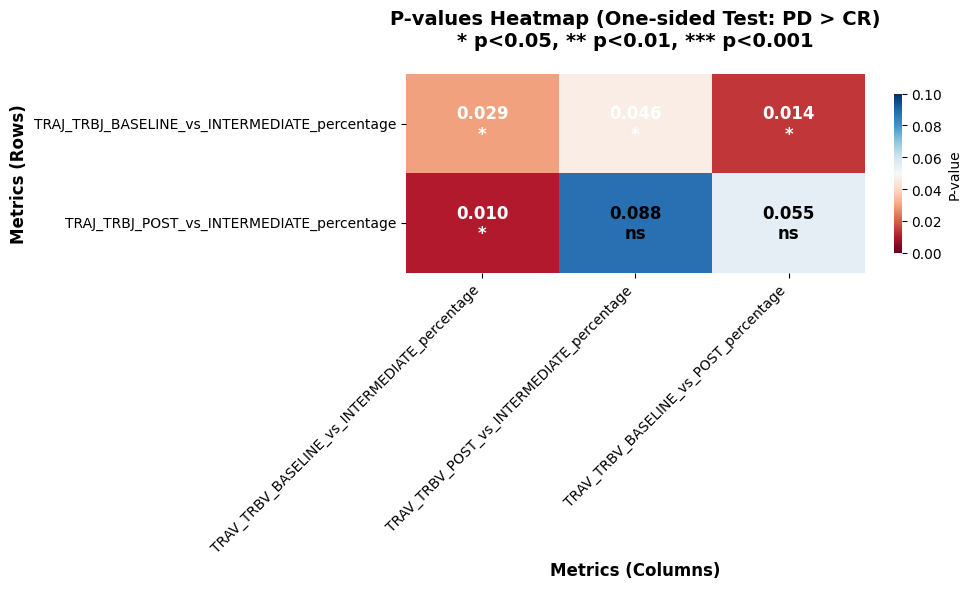

In [22]:
# Create 2x3 heatmap for p-values
fig, ax = plt.subplots(figsize=(10, 6))

# Reshape p-values into 2x3 matrix
p_values = results_df['P_Value'].values
if len(p_values) == 6:
    # Reshape to 2x3 (2 rows, 3 columns)
    p_value_matrix = p_values.reshape(2, 3)
elif len(p_values) == 9:
    # If you have 9 metrics, take first 6 or reshape to 3x3
    p_value_matrix = p_values[:6].reshape(2, 3)
else:
    # Pad with NaN if needed
    padded_values = np.pad(p_values, (0, 6 - len(p_values)), constant_values=np.nan)
    p_value_matrix = padded_values[:6].reshape(2, 3)

# Create the heatmap using seaborn
import seaborn as sns
im = sns.heatmap(p_value_matrix, 
                 cmap='RdBu', 
                 vmin=0, vmax=0.1,
                 cbar_kws={'label': 'P-value', 'shrink': 0.8},
                 square=False,
                 annot=False,  # We'll add custom annotations
                 ax=ax)

# Add text annotations with p-values
for i in range(2):
    for j in range(3):
        if not np.isnan(p_value_matrix[i, j]):
            # Determine text color based on significance
            text_color = 'white' if p_value_matrix[i, j] < 0.05 else 'black'
            
            # Add significance symbols
            if p_value_matrix[i, j] < 0.001:
                symbol = '***'
            elif p_value_matrix[i, j] < 0.01:
                symbol = '**'
            elif p_value_matrix[i, j] < 0.05:
                symbol = '*'
            else:
                symbol = 'ns'
            
            ax.text(j + 0.5, i + 0.5, f'{p_value_matrix[i, j]:.3f}\n{symbol}', 
                   ha='center', va='center', fontsize=12, fontweight='bold', 
                   color=text_color)

metric_labels = results_df['Metric'].values

# Set labels
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels([metric_labels[i] if i < len(metric_labels) else '' for i in [0, 1, 2]], 
                   fontsize=10, rotation=45, ha='right')
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels([metric_labels[i] if i < len(metric_labels) else '' for i in [3, 4]], 
                   fontsize=10, rotation=0)

# Add row and column labels
ax.set_xlabel('Metrics (Columns)', fontsize=12, fontweight='bold')
ax.set_ylabel('Metrics (Rows)', fontsize=12, fontweight='bold')

# Add title
ax.set_title('P-values Heatmap (One-sided Test: PD > CR)\n* p<0.05, ** p<0.01, *** p<0.001', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/mnt/d/TCRMI/figures/cHL/samples/VJpair-changed_pvalues.pdf')

# Print the matrix values for reference
print("P-value Matrix (2×3):")
print("Rows represent different metrics, Columns represent different metrics")
print(f"Matrix shape: {p_value_matrix.shape}")
print("\nP-values:")
for i in range(2):
    for j in range(3):
        if not np.isnan(p_value_matrix[i, j]):
            metric_idx = i * 3 + j
            if metric_idx < len(metric_labels):
                print(f"Position [{i},{j}] - {metric_labels[metric_idx]}: {p_value_matrix[i, j]:.4f}")
